In [ ]:
from sequana import FastA
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio import Phylo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [46]:
fastaInf = "../../data/Fasta/genomes/Linfantum/TriTrypDB-68_LinfantumJPCM5_Genome.fasta"
fastaDono = "../../data/Fasta/genome.fasta"
fastaTrop = "../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta"

In [47]:
gffInf = "../../data/Fasta/genomes/Linfantum/Linfantum.gff"
gffDono = "../../data/Fasta/genome.gff"
gffTrop = "../../data/Fasta/genomes/Ltropica/Ltropica.gff"


In [67]:
def load_fasta(fasta_path,name, resultat):
    f = FastA(fasta_path)
    sequences = []

    for maseq in f:
        chrom = resultat['Chrom']
        if maseq.name == f"{chrom}" or maseq.name.endswith(f".{chrom}"):
            seq = maseq.sequence.upper()
            seq = seq[resultat['Start']:resultat['End']]
                
            record = SeqRecord(Seq(str(seq)), id=name, description='')

            with open('intergenic.fasta', "a") as output_handle:
                SeqIO.write(record, output_handle, "fasta")

In [50]:
def extraire_gene_par_annotation(nom_fichier, annotation_recherchee):
    resultats = []

    with open(nom_fichier, 'r') as fichier:
        for ligne in fichier:
            if ligne.startswith('#') or not ligne.strip():
                continue  # ignorer les commentaires et lignes vides

            colonnes = ligne.strip().split('\t')
            if len(colonnes) != 9:
                continue  # ignorer les lignes malformées

            seqid, source, type_, start, end, score, strand, phase, attributs = colonnes

            # Séparer les attributs proprement (en ne prenant que le premier '=')
            attribut_dict = {}
            for item in attributs.split(';'):
                if '=' in item:
                    key, value = item.split('=', 1)  # <= ici : on ne split qu'une fois
                    attribut_dict[key.strip()] = value.strip()

            if 'combinedAnnotation' in attribut_dict and annotation_recherchee in attribut_dict['combinedAnnotation'].lower():
                resultats.append({
                    'Chrom': seqid,
                    'Annotation': attribut_dict['combinedAnnotation'],
                    'id': attribut_dict['ID'],
                    'gene_id': attribut_dict['gene_id'],
                    'Start': int(start),
                    'End': int(end)
                })

    return resultats


def afficher_tableau(resultats):
    if not resultats:
        print("Aucune annotation trouvée.")
        return

    print(f"{'Chrom':<10}{'Annotation':<25}{'Start':<10}{'End':<10}")
    print("-" * 50)
    for entree in resultats:
        print(f"{entree['Chrom']:<10}{entree['Annotation']:<25}{entree['Start']:<10}{entree['End']:<10}")

In [63]:
annotation = 'histone h3'

print("Infatum")
resultats = extraire_gene_par_annotation(gffInf, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    ID = resultat['gene_id']
    name = resultat['Chrom']
    load_fasta(fastaInf,f"Linfantum{name}_{ID}",resultat)

print("\n Donovani")
resultats = extraire_gene_par_annotation(gffDono, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    ID = resultat['gene_id']
    name = resultat['Chrom']
    load_fasta(fastaDono,f'Ldonovani{name}_{ID}',resultat)

print("\n Tropicana")
resultats = extraire_gene_par_annotation(gffTrop, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    ID = resultat['gene_id']
    name = resultat['Chrom']
    load_fasta(fastaTrop,f'Ltropica{name}__{ID}',resultat)

Infatum
Chrom     Annotation               Start     End       
--------------------------------------------------
10        histone H3               432074    432466    
10        histone H3               469169    469561    
10        histone H3               474582    474974    
19        histone H3 variant V     272937    273374    

 Donovani
Chrom     Annotation               Start     End       
--------------------------------------------------
10        histone H3               496347    496739    
10        histone H3               533463    533855    
10        histone H3               538891    539283    
19        histone H3 variant V     300088    300525    

 Tropicana
Chrom     Annotation               Start     End       
--------------------------------------------------
10        histone H3               403781    404173    
10        histone H3               441631    442023    
10        histone H3               447052    447444    
19        histone H3 variant V  

In [52]:
annotation = 'amastin'

print("Infatum")
resultats = extraire_gene_par_annotation(gffInf, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    if  resultat['Chrom'] == '34':
        ID = resultat['gene_id']
        load_fasta(fastaInf,f"Linfantum_{ID}",resultat)

print("\n Donovani")
resultats = extraire_gene_par_annotation(gffDono, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    if  resultat['Chrom'] == "34":
        ID = resultat['gene_id']
        load_fasta(fastaDono,f'Ldonovani_{ID}',resultat)

print("\n Tropicana")
resultats = extraire_gene_par_annotation(gffTrop, annotation)
afficher_tableau(resultats)
for resultat in resultats:
    if  resultat['Chrom'] == "34":   
        ID = resultat['gene_id']
        load_fasta(fastaTrop,f'Ltropica_{ID}',resultat)

Infatum
Chrom     Annotation               Start     End       
--------------------------------------------------
10        Amastin surface glycoprotein, putative102688    104160    
10        Amastin surface glycoprotein, putative108043    109299    
14        Amastin surface glycoprotein, putative177532    178356    
14        amastin-like surface protein-like protein. Function unknown183097    183924    
24        amastin-like surface protein-like protein fragment455165    455725    
24        amastin-like surface protein-like protein458630    459148    
24        amastin-like surface protein-like protein461113    461637    
24        amastin-like surface protein-like protein fragment465620    466180    
27        Amastin surface glycoprotein, putative249092    249721    
28        Amastin-like surface protein. Function unknown420390    421154    
28        Amastin surface glycoprotein, putative424143    425702    
28        Amastin surface glycoprotein, putative517768    518796   

In [68]:
def extraire_gene_par_position(nom_fichier,chrom, start_p,end_p):
    resultats = []

    with open(nom_fichier, 'r') as fichier:
        for ligne in fichier:
            if ligne.startswith('#') or not ligne.strip():
                continue  # ignorer les commentaires et lignes vides

            colonnes = ligne.strip().split('\t')
            if len(colonnes) != 9:
                continue  # ignorer les lignes malformées

            seqid, source, type_, start, end, score, strand, phase, attributs = colonnes

            # Séparer les attributs proprement (en ne prenant que le premier '=')
            attribut_dict = {}
            for item in attributs.split(';'):
                if '=' in item:
                    key, value = item.split('=', 1)  # <= ici : on ne split qu'une fois
                    attribut_dict[key.strip()] = value.strip()

            if seqid == str(chrom):
                if int(start) >= start_p and int(end) <= end_p:
                    resultats.append({
                        'Chrom': seqid,
                        'Annotation': attribut_dict['combinedAnnotation'],
                        'id': attribut_dict['ID'],
                        'gene_id': attribut_dict['gene_id'],
                        'Start': int(start),
                        'End': int(end)
                    })

    return resultats

def extraire_gene_par_id(nom_fichier,ids_p):
    resultats = []

    with open(nom_fichier, 'r') as fichier:
        for ligne in fichier:
            if ligne.startswith('#') or not ligne.strip():
                continue  # ignorer les commentaires et lignes vides

            colonnes = ligne.strip().split('\t')
            if len(colonnes) != 9:
                continue  # ignorer les lignes malformées

            seqid, source, type_, start, end, score, strand, phase, attributs = colonnes

            # Séparer les attributs proprement (en ne prenant que le premier '=')
            attribut_dict = {}
            for item in attributs.split(';'):
                if '=' in item:
                    key, value = item.split('=', 1)  # <= ici : on ne split qu'une fois
                    attribut_dict[key.strip()] = value.strip()

            if attribut_dict['ID'] in ids_p:
             
                resultats.append({
                    'Chrom': seqid,
                    'Annotation': attribut_dict['combinedAnnotation'],
                    'id': attribut_dict['ID'],
                    'gene_id': attribut_dict['gene_id'],

                    'Start': int(start),
                    'End': int(end)
                })

    return resultats



print("\n Donovani")
resultats = extraire_gene_par_position(gffDono,34, 940000,1000000)
afficher_tableau(resultats)
#for resultat in resultats:
#    ID = resultat['Name']
#    load_fasta(fastaDono,f'LDonovani_{ID}',resultat)
print(len(resultats))
ids = []
for resultat in resultats:
    ids.append(resultat['id'])

    
for i in range(len(resultats)-1):
    
    resultat = {
        'Chrom': resultats[i]['Chrom'],
        'id': resultats[i]['gene_id']+"_"+resultats[i+1]['gene_id'],
        'Start': int(resultats[i]['End']),
        'End': int(resultats[i+1]['Start'])
    }
    ID = resultat['id']
    load_fasta(fastaDono,f'LDonovani_{ID}',resultat)

    

print("\n Tropicana")
resultats = extraire_gene_par_id(gffTrop, ids)
afficher_tableau(resultats)
for i in range(len(resultats)-1):
    resultat = {
        'Chrom': resultats[i]['Chrom'],
        'id': resultats[i]['gene_id']+"_"+resultats[i+1]['gene_id'],
        'Start': int(resultats[i]['End']),
        'End': int(resultats[i+1]['Start'])
    }
    ID = resultat['id']
    load_fasta(fastaTrop,f'Ltropica_{ID}',resultat)
    
print("Infatum")
resultats = extraire_gene_par_id(gffInf, ids)
afficher_tableau(resultats)
for i in range(len(resultats)-1):
    resultat = {
        'Chrom': resultats[i]['Chrom'],
        'id': resultats[i]['gene_id']+"_"+resultats[i+1]['gene_id'],
        'Start': int(resultats[i]['End']),
        'End': int(resultats[i+1]['Start'])
    }
    ID = resultat['id']
    load_fasta(fastaInf,f'Linfantum_{ID}',resultat)
    



 Donovani
Chrom     Annotation               Start     End       
--------------------------------------------------
34        pyroglutamyl-peptidase I, putative940823    941656    
34        hypothetical protein     943580    944059    
34        Regulator of chromosome condensation RCC1 repeat, putative945879    947768    
34        IQ calmodulin-binding motif containing protein, putative949358    952873    
34        hypothetical protein     960830    962080    
34        ATP-dependent RNA helicase, putative967240    969651    
34        hypothetical protein     970392    971339    
34        FtsX-like permease family, putative973017    976403    
34        hypothetical protein     980408    981358    
34        hypothetical protein     982922    988567    
34        protein kinase, putative 990240    991397    
34        hypothetical protein     993855    996365    
12

 Tropicana
Chrom     Annotation               Start     End       
---------------------------------------------

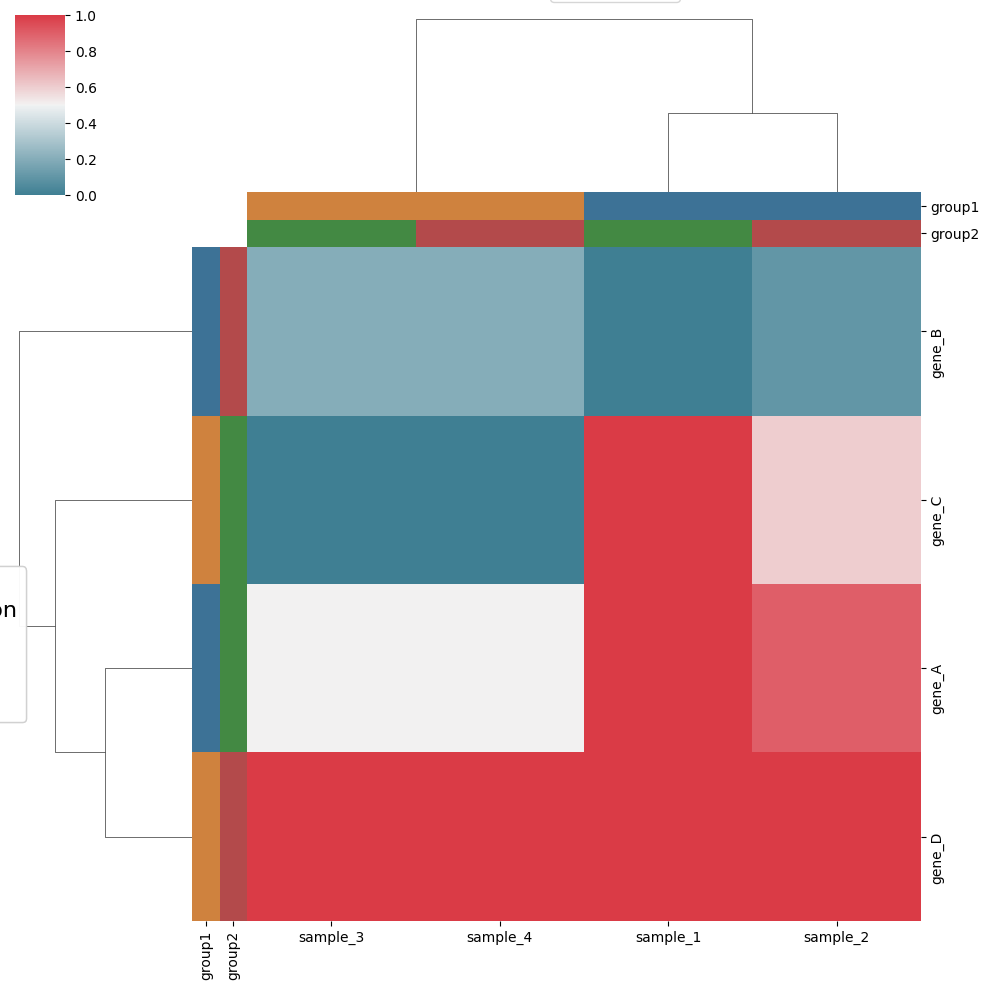

In [1]:
from sequana.viz.heatmap import Clustermap, get_clustermap_data
df, sample_groups_df, gene_groups_df = get_clustermap_data()
h = Clustermap(df, sample_groups_df=sample_groups_df, gene_groups_df=gene_groups_df)
h.plot()

In [7]:
from ete3 import Tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger l'arbre
t = Tree("mafft-I20250731-151358-0333-17019200-p1m.phylotree", format=1)

# Obtenir la liste des taxons
taxa = [leaf.name for leaf in t.iter_leaves()]

# Calculer la matrice de distances
distance_matrix = pd.DataFrame(index=taxa, columns=taxa)

for i in taxa:
    for j in taxa:
        distance_matrix.loc[i, j] = t.get_distance(i, j)

# Convertir en float (optionnel si c’est object)
distance_matrix = distance_matrix.astype(float)


ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
sns.heatmap(distance_matrix, cmap="viridis")
plt.title("Distance phylogénétique entre individus")
plt.show()


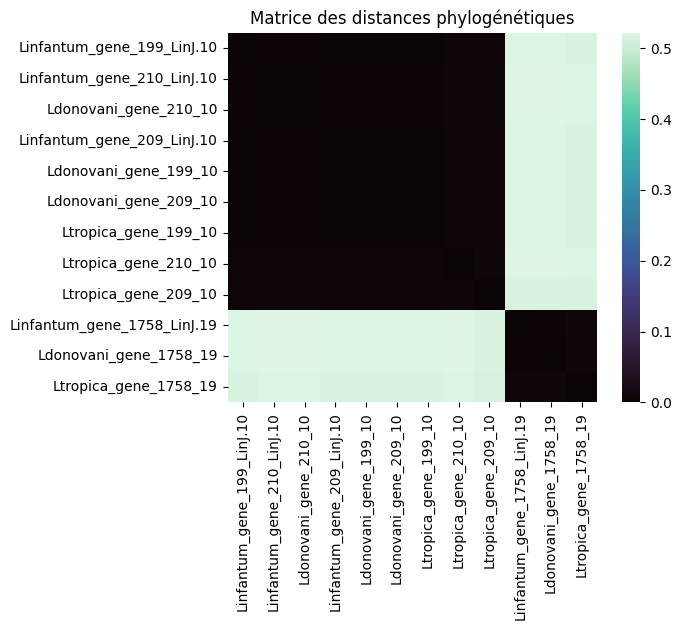

In [7]:

# Lire l’arbre depuis un fichier .phylotree (supposé être au format Newick)
tree = Phylo.read("mafft-I20250731-151358-0333-17019200-p1m.phylotree", "newick")

# Extraire tous les taxons (feuilles)
taxa = [term.name for term in tree.get_terminals()]

# Construire une matrice de distances
distance_matrix = pd.DataFrame(index=taxa, columns=taxa)

for i in taxa:
    for j in taxa:
        distance = tree.distance(i, j)
        distance_matrix.loc[i, j] = distance

# Convertir en float
distance_matrix = distance_matrix.astype(float)

# Afficher la heatmap
sns.heatmap(distance_matrix, cmap="mako", square=True)
plt.title("Matrice des distances phylogénétiques")
plt.show()


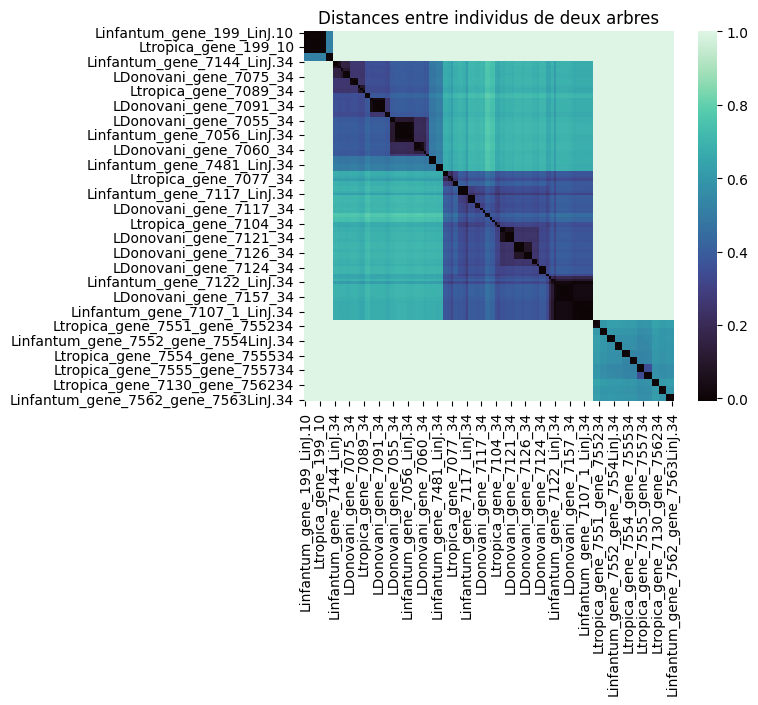

<Figure size 640x480 with 0 Axes>

In [57]:
from Bio import Phylo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Bio import Phylo
import pandas as pd

# Charger les trois arbres
tree1 = Phylo.read("mafft-I20250731-151358-0333-17019200-p1m.phylotree", "newick")
tree2 = Phylo.read("amestinAll.phylotree", "newick")
tree3 = Phylo.read("intergenic.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]
taxa2 = [term.name for term in tree2.get_terminals()]
taxa3 = [term.name for term in tree3.get_terminals()]

# Créer une matrice de distances complète
all_taxa = taxa1 + taxa2 + taxa3
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Distances intra-arbre 2
for i in taxa2:
    for j in taxa2:
        distance_matrix.loc[i, j] = tree2.distance(i, j)

# Distances intra-arbre 3
for i in taxa3:
    for j in taxa3:
        distance_matrix.loc[i, j] = tree3.distance(i, j)

# Distances inter-arbres : entre tree1 et tree2
for i in taxa1:
    for j in taxa2:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Distances inter-arbres : entre tree1 et tree3
for i in taxa1:
    for j in taxa3:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Distances inter-arbres : entre tree2 et tree3
for i in taxa2:
    for j in taxa3:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Convertir en float
distance_matrix = distance_matrix.astype(float)


# Heatmap
sns.heatmap(distance_matrix, cmap="mako", square=True)
plt.title("Distances entre individus de deux arbres")
plt.show()
plt.savefig("heatmap_phylogenetique.png")


<Figure size 640x480 with 0 Axes>

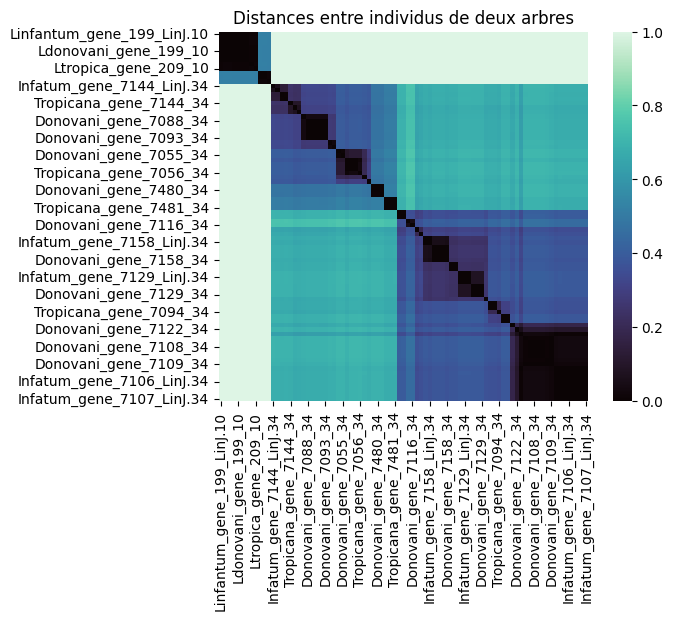

In [12]:
sns.heatmap(distance_matrix, cmap="mako", square=True)
plt.title("Distances entre individus de deux arbres")

# Sauvegarder la heatmap
plt.savefig("heatmap_phylogenetique.png", dpi=300, bbox_inches='tight')

# Afficher dans la console
plt.show()


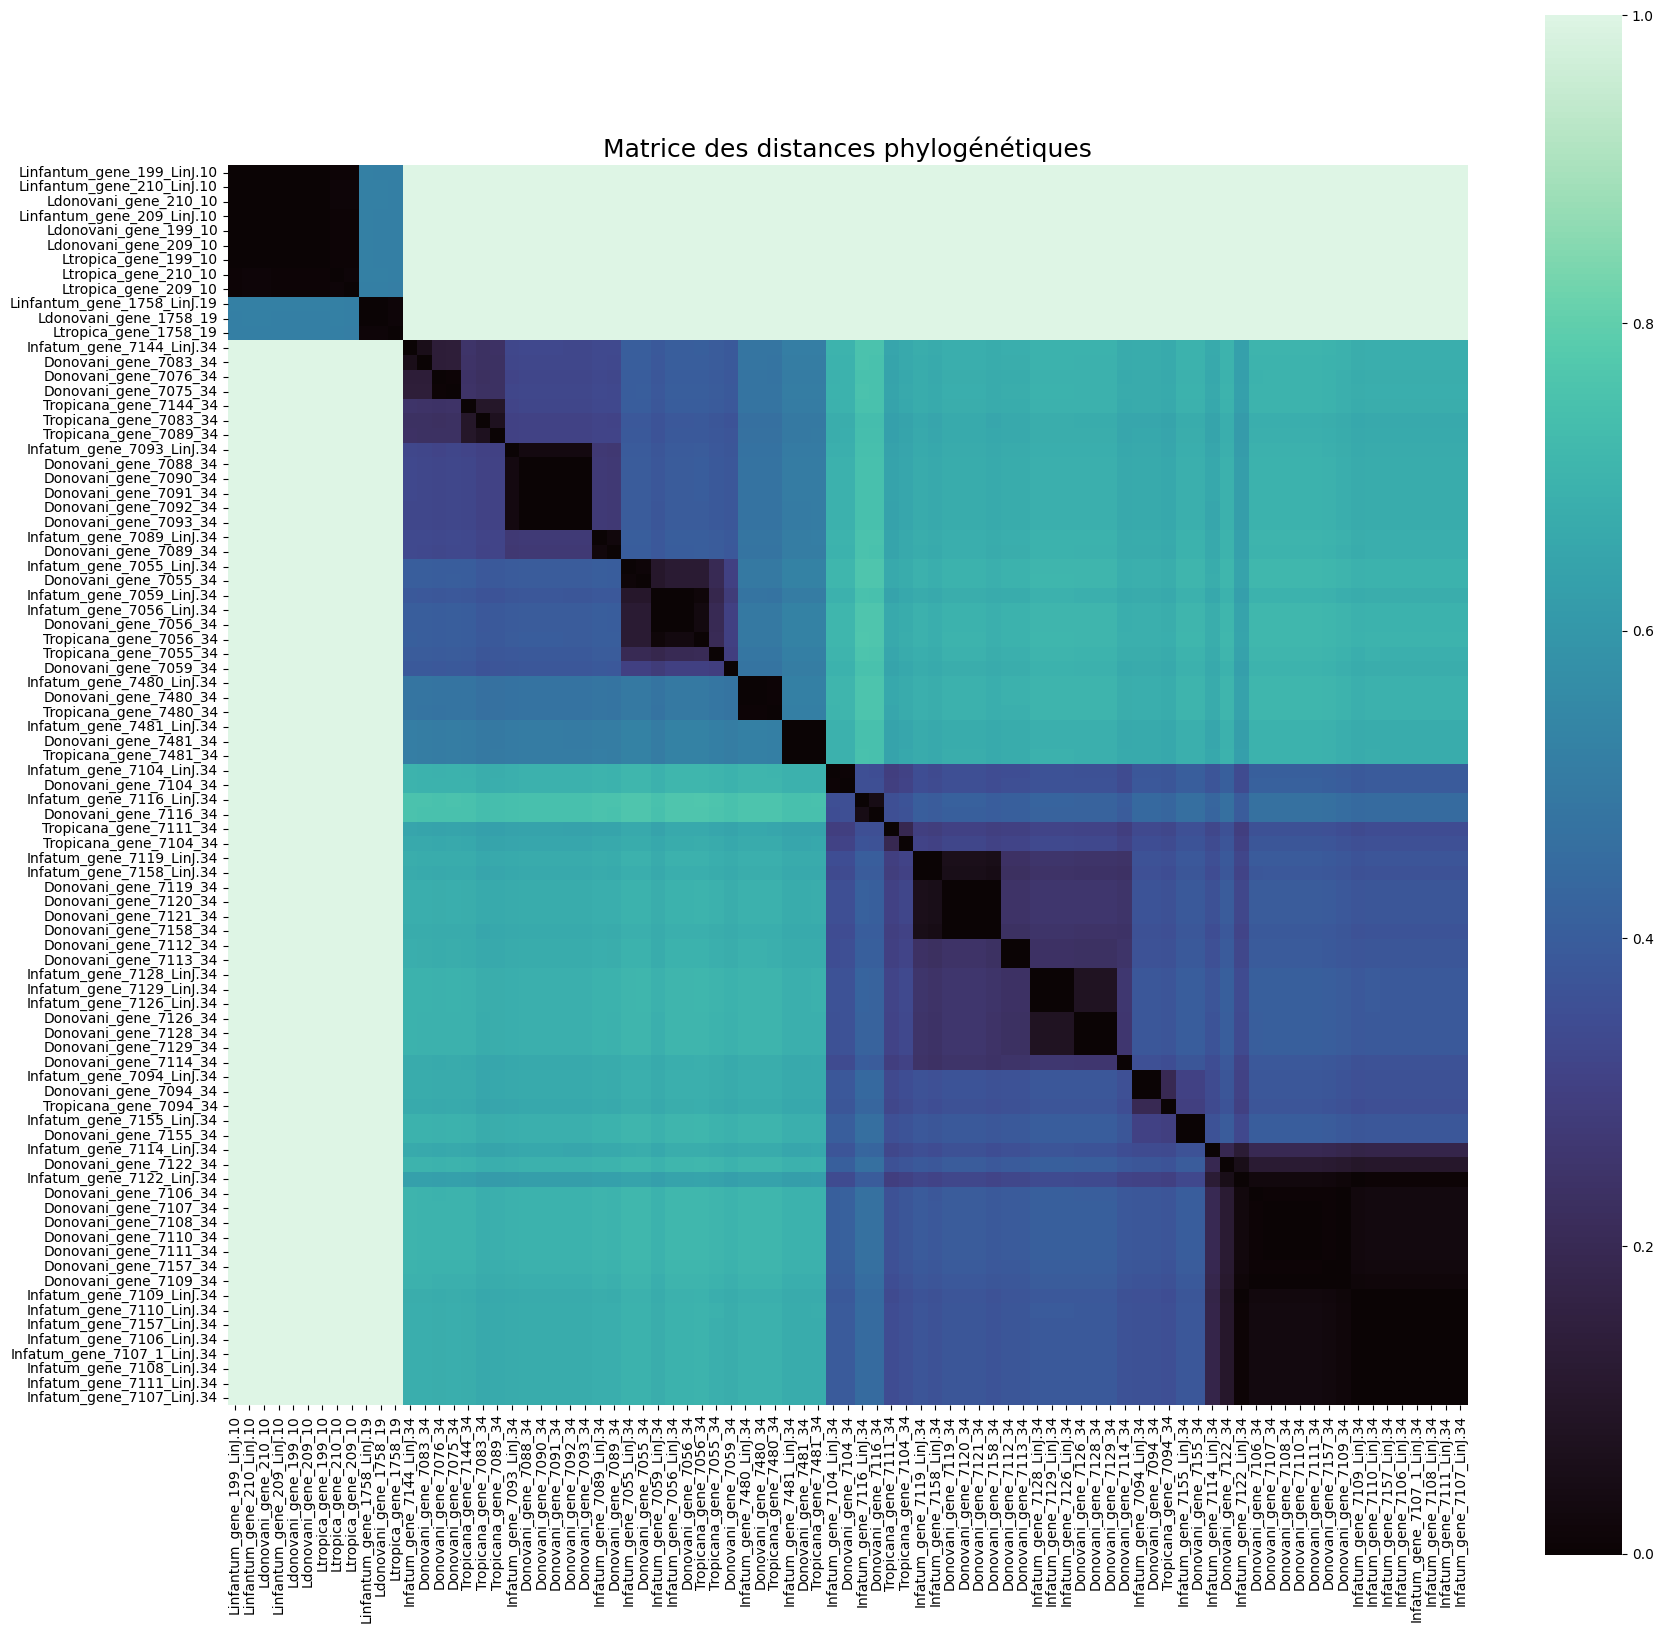

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))  # Large figure
sns.heatmap(distance_matrix, cmap="mako", square=True)

plt.title("Matrice des distances phylogénétiques", fontsize=18)

# Sauvegarde haute résolution
plt.savefig("heatmap_phylogenetique.png", dpi=600, bbox_inches='tight')

plt.show()


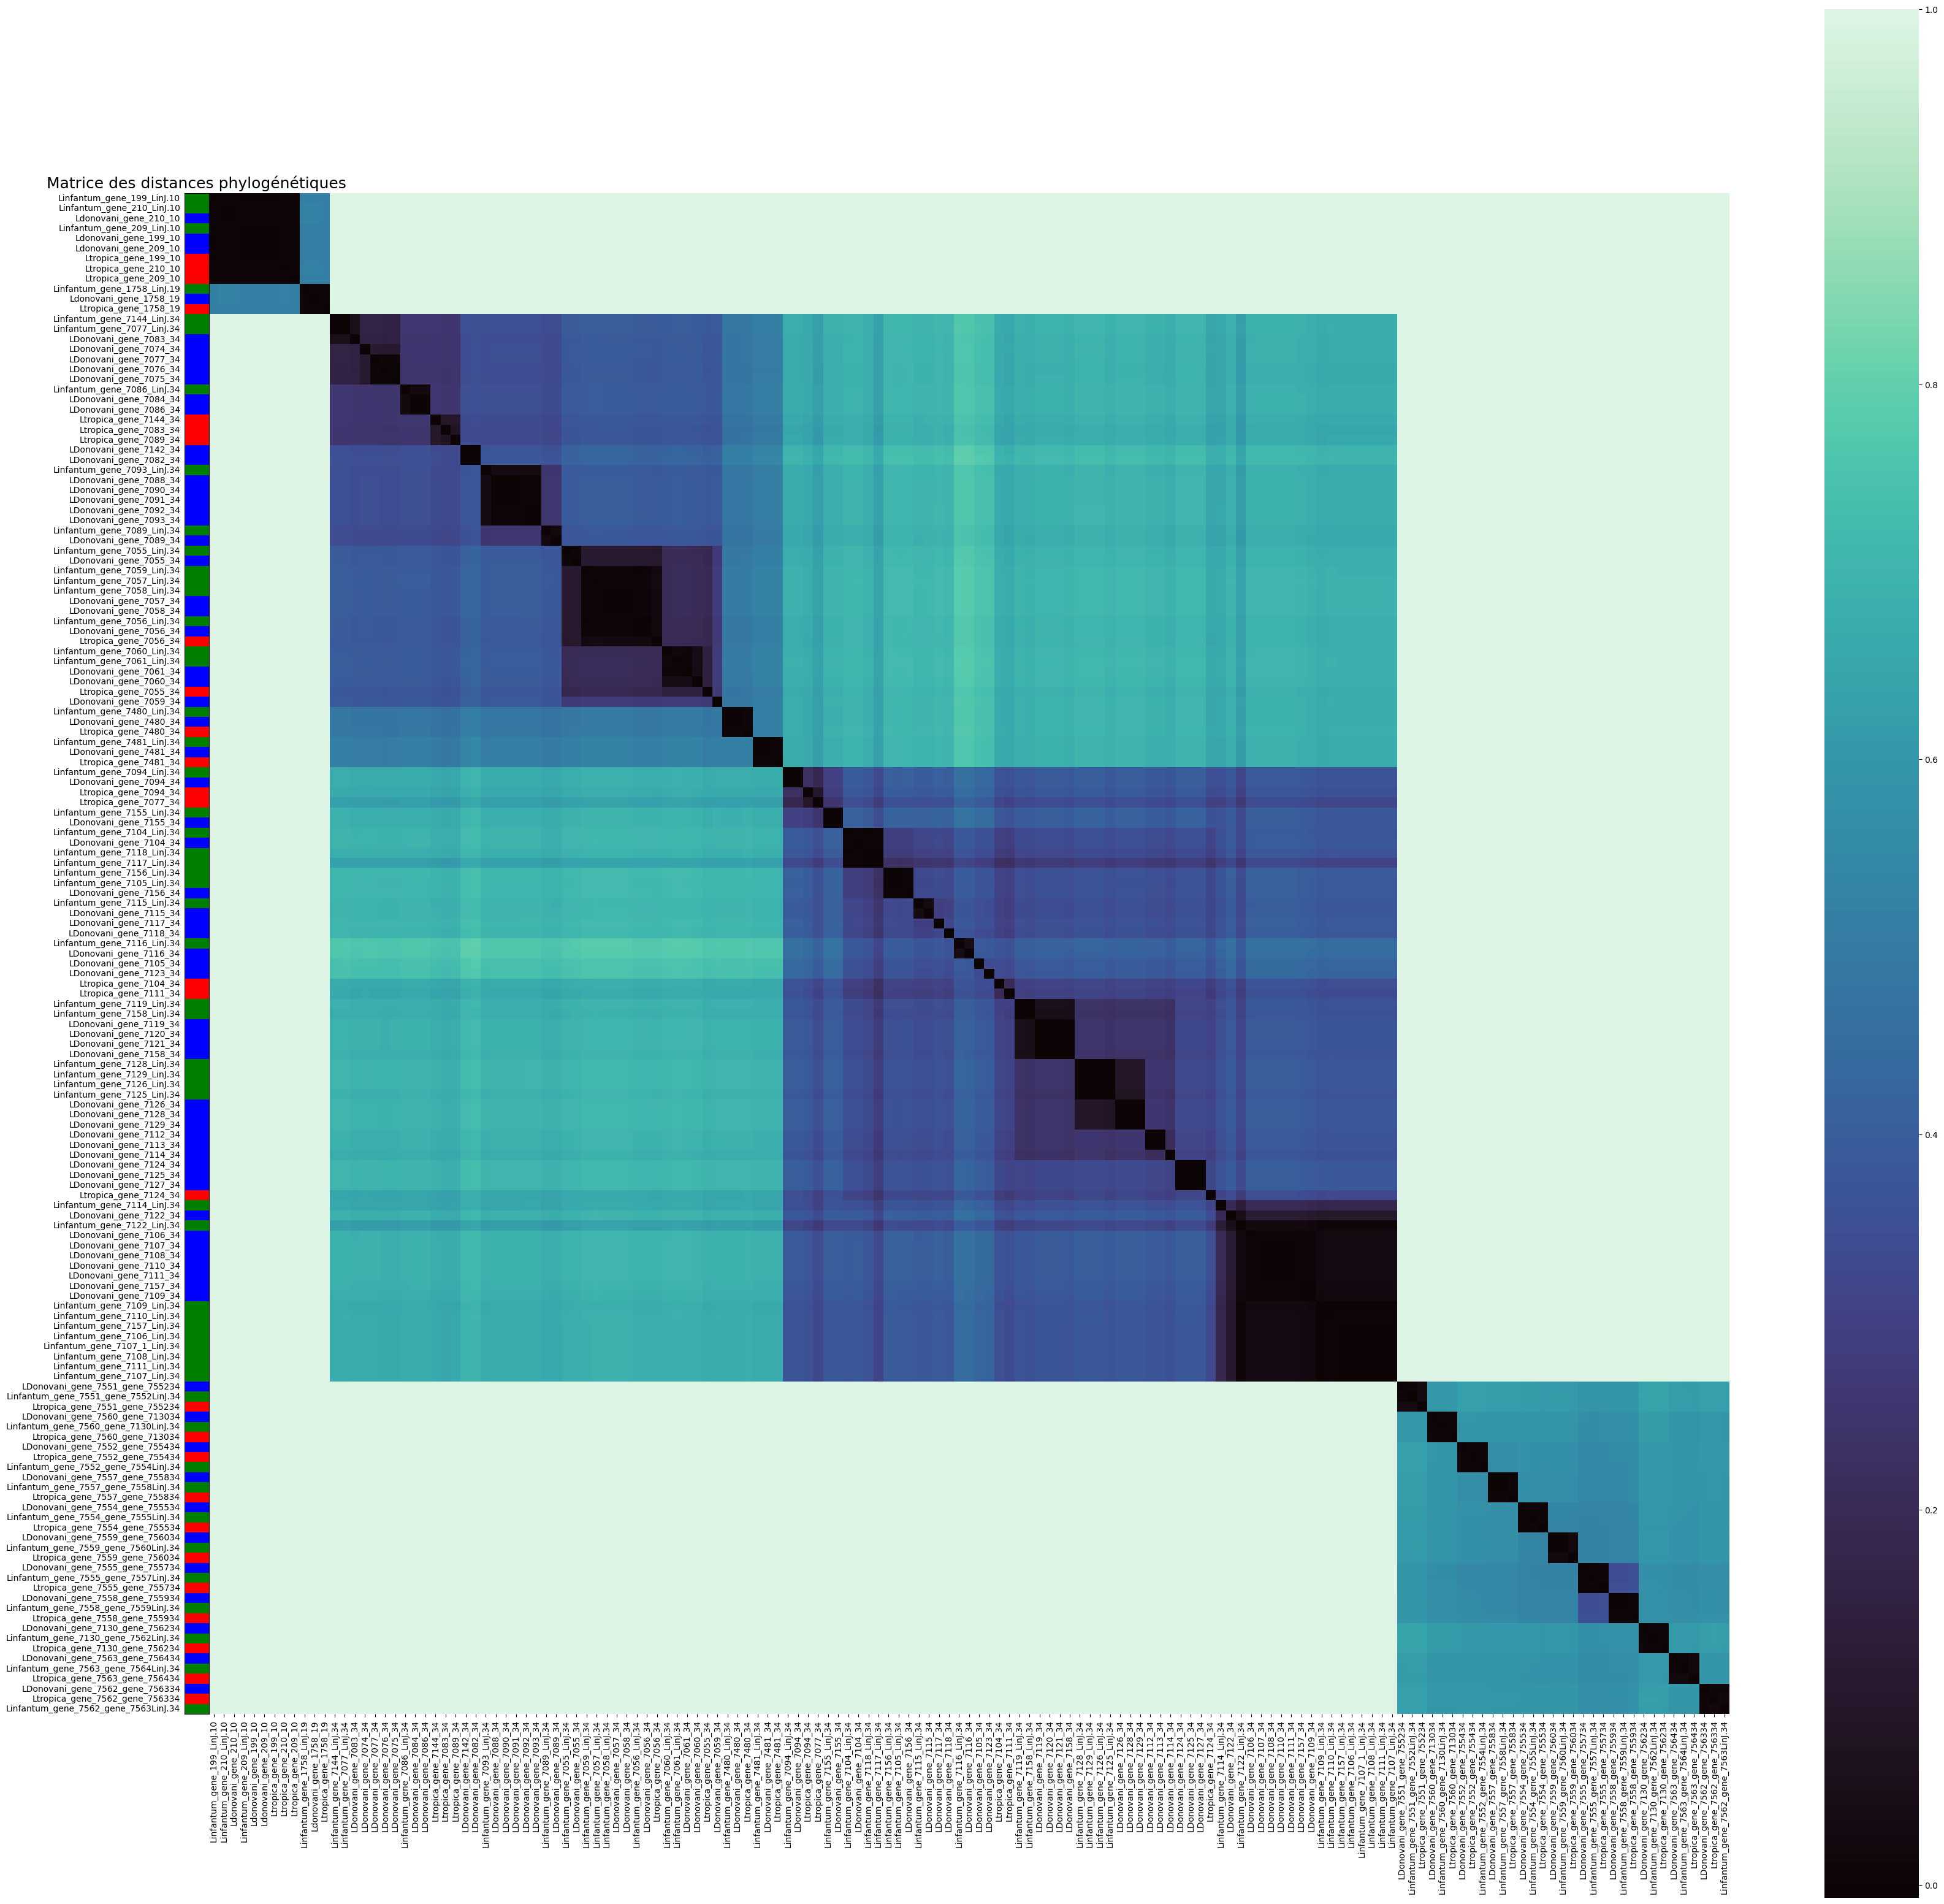

In [68]:

plt.figure(figsize=(40, 40))
ax = sns.heatmap(distance_matrix, cmap="mako", square=True)

labels = distance_matrix.index.tolist()

# Créer une liste de couleurs selon le groupe
colors = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors.append("red")
    elif "infa" in name_low:
        colors.append("green")
    elif "dono" in name_low:
        colors.append("blue")
    else:
        colors.append("gray")  # couleur pour les autres

# Ajouter une barre de couleur à côté de l'axe y
# On crée un mini-heatmap avec 1 colonne et autant de lignes que de labels, avec ces couleurs
# On utilise une nouvelle axes à gauche

from matplotlib.colors import ListedColormap

# Créer une colormap personnalisée pour correspondre aux couleurs
cmap = ListedColormap(colors)

# Nouvel axe pour le code couleur
ax_colors = plt.gcf().add_axes([ax.get_position().x0-0.01 ,  # à gauche de la heatmap
                                ax.get_position().y0,
                                0.01,  # largeur petite bande
                                ax.get_position().height])

# Transforme les couleurs en valeurs numériques pour l'affichage
color_vals = np.arange(len(colors)).reshape(-1, 1)

# Affiche la bande couleur (1 colonne x N lignes)
ax_colors.imshow(color_vals, aspect='auto', cmap=cmap)




# Enlève ticks et labels sur cette bande
ax_colors.set_xticks([])
ax_colors.set_yticks([])

# Ajuster l'axe principal pour que les labels soient visibles
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.tick_params(axis='y', pad=30)  # augmente le padding (espace) entre ticks et labels y

plt.title("Matrice des distances phylogénétiques", fontsize=18)
plt.savefig("heatmap_phylogenetique_couleurs_groupes.png", dpi=600, bbox_inches='tight')
plt.show()


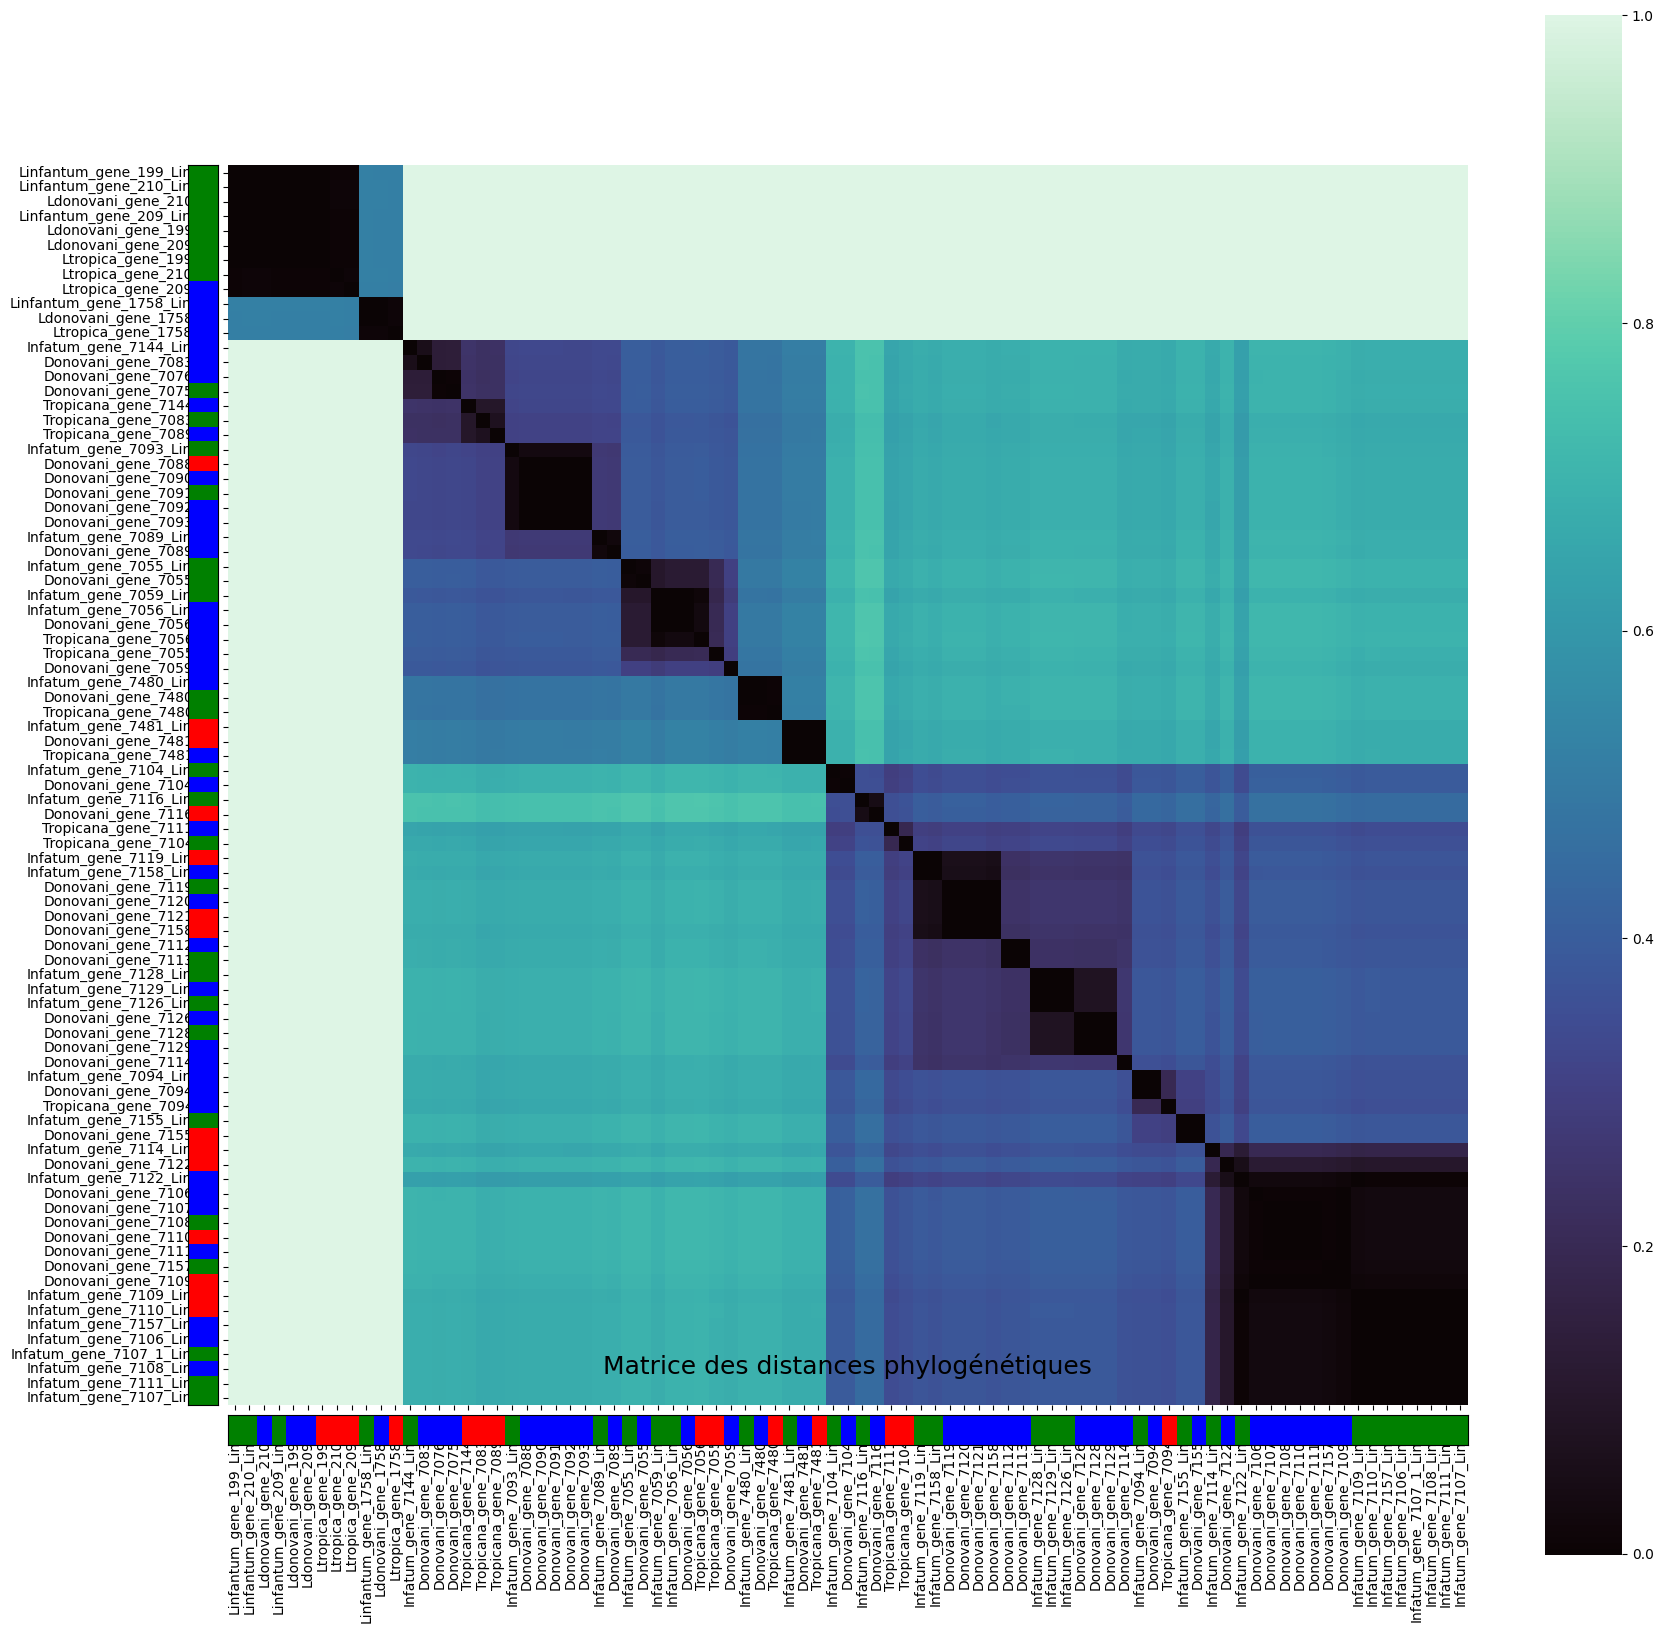

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

plt.figure(figsize=(20, 20))
ax = sns.heatmap(distance_matrix, cmap="mako", square=True)

# Labels sur les axes y et x
labels_y = distance_matrix.index.tolist()
labels_x = distance_matrix.columns.tolist()

# Créer liste de couleurs pour l'axe y (comme avant)
colors_y = []
for name in labels_y:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_y.append("red")
    elif "infa" in name_low:
        colors_y.append("green")
    elif "dono" in name_low:
        colors_y.append("blue")
    else:
        colors_y.append("gray")

# Créer liste de couleurs pour l'axe x (colonnes)
colors_x = []
for name in labels_x:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_x.append("red")
    elif "infa" in name_low:
        colors_x.append("green")
    elif "dono" in name_low:
        colors_x.append("blue")
    else:
        colors_x.append("gray")

cmap_y = ListedColormap(colors_y)
cmap_x = ListedColormap(colors_x)

# Position et taille de la heatmap
pos = ax.get_position()

# Bande verticale à gauche (axe y)
ax_colors_y = plt.gcf().add_axes([pos.x0 - 0.02, pos.y0, 0.015, pos.height])
color_vals_y = np.arange(len(colors_y)).reshape(-1, 1)
ax_colors_y.imshow(color_vals_y, aspect='auto', cmap=cmap_y)
ax_colors_y.set_xticks([])
ax_colors_y.set_yticks([])
ax_colors_y.invert_yaxis()  # Pour que les couleurs correspondent à l'ordre des labels y

# Bande horizontale en bas (axe x)
ax_colors_x = plt.gcf().add_axes([pos.x0, pos.y0 - 0.02, pos.width, 0.015])
color_vals_x = np.arange(len(colors_x)).reshape(1, -1)
ax_colors_x.imshow(color_vals_x, aspect='auto', cmap=cmap_x)
ax_colors_x.set_xticks([])
ax_colors_x.set_yticks([])

# Ajustements des ticks labels
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position("bottom")

plt.title("Matrice des distances phylogénétiques", fontsize=18, pad=30)

plt.savefig("heatmap_phylogenetique_couleurs_groupes_xy_bas.png", dpi=600, bbox_inches='tight')
plt.show()


In [59]:
# Exemple d'utilisation
annotation = 'amastin'

print("Infatum")
resultats = extraire_gene_par_annotation(gffInf, annotation)
afficher_tableau(resultats)
#for resultat in resultats:
#    if  resultat['Chrom'] == '34':
#        ID = resultat['id']
#        load_fasta(fastaInf,f"Linfantum_{ID}_",resultat)

print("\n Donovani")
resultats = extraire_gene_par_annotation(gffDono, annotation)
afficher_tableau(resultats)
#for resultat in resultats:
#    if  resultat['Chrom'] == "34":
#        ID = resultat['id']
#        load_fasta(fastaDono,f'LDonovani_{ID}_',resultat)

print("\n Tropicana")
resultats = extraire_gene_par_annotation(gffTrop, annotation)
afficher_tableau(resultats)
#for resultat in resultats:
#    if  resultat['Chrom'] == "34":   
#        ID = resultat['id']
#        load_fasta(fastaTrop,f'Ltropica_{ID}_',resultat)

Infatum
Chrom     Annotation               Start     End       
--------------------------------------------------
10        Amastin surface glycoprotein, putative102688    104160    
10        Amastin surface glycoprotein, putative108043    109299    
14        Amastin surface glycoprotein, putative177532    178356    
14        amastin-like surface protein-like protein. Function unknown183097    183924    
24        amastin-like surface protein-like protein fragment455165    455725    
24        amastin-like surface protein-like protein458630    459148    
24        amastin-like surface protein-like protein461113    461637    
24        amastin-like surface protein-like protein fragment465620    466180    
27        Amastin surface glycoprotein, putative249092    249721    
28        Amastin-like surface protein. Function unknown420390    421154    
28        Amastin surface glycoprotein, putative424143    425702    
28        Amastin surface glycoprotein, putative517768    518796   

In [55]:
def groupe(resultats):
    distance_threshold = 30000  # Ajuste la distance max pour grouper
    
    # Trier la liste par Chrom et Start
    resultats = sorted(resultats, key=lambda x: (x['Chrom'], x['Start']))
    
    group_id = 1
    current_group_max_end = -1
    current_chrom = None
    
    for i, region in enumerate(resultats):
        chrom = region['Chrom']
        start = region['Start']
        end = region['End']
    
        if i == 0:
            # premier élément
            region['Group'] = group_id
            current_group_max_end = end
            current_chrom = chrom
        else:
            if chrom == current_chrom and start <= current_group_max_end + distance_threshold:
                # même chromosome et proche -> même groupe
                region['Group'] = group_id
                current_group_max_end = max(current_group_max_end, end)
            else:
                # nouveau groupe
                group_id += 1
                region['Group'] = group_id
                current_group_max_end = end
                current_chrom = chrom
    return resultats

    
annotation = 'amastin'

print("\n Donovani")
resultats = extraire_gene_par_annotation(gffDono, annotation)
print("---------------------------------------------------------------------------")
resultats = [r for r in resultats if r['Chrom'] == '34']
resultats = groupe(resultats)
resultats_color = []
# Exemple d'affichage
for r in resultats:
    ID = r['gene_id']
    resultats_color.append({
        'name': f'Ldonovani_{ID}',
        'group': r['Group'],

    })
    print(f"Chrom {r['Chrom']} | {r['id']} | {r['Start']}-{r['End']} | Groupe {r['Group']}")




print("\n Infatum")
resultats = extraire_gene_par_annotation(gffInf, annotation)
print("---------------------------------------------------------------------------")
resultats = [r for r in resultats if r['Chrom'] == '34']
resultats = groupe(resultats)
# Exemple d'affichage
for r in resultats:
    ID = r['gene_id']
    resultats_color.append({
        'name': f"Linfantum_{ID}",
        'group': r['Group'],

    })
    print(f"Chrom {r['Chrom']} | {r['id']} | {r['Start']}-{r['End']} | Groupe {r['Group']}")


print("\n Tropicana")
resultats = extraire_gene_par_annotation(gffTrop, annotation)
print("---------------------------------------------------------------------------")
resultats = [r for r in resultats if r['Chrom'] == '34']
resultats = groupe(resultats)
# Exemple d'affichage
for r in resultats:
    ID = r['gene_id']
    resultats_color.append({
        'name': f'Ltropica_{ID}',
        'group': r['Group'],

    })
    print(f"Chrom {r['Chrom']} | {r['id']} | {r['Start']}-{r['End']} | Groupe {r['Group']}")

print(resultats_color)





 Donovani
---------------------------------------------------------------------------
Chrom 34 | gene_7074 | 209809-210459 | Groupe 1
Chrom 34 | gene_7077 | 213286-213854 | Groupe 1
Chrom 34 | gene_7076 | 216775-217425 | Groupe 1
Chrom 34 | gene_7075 | 220268-220918 | Groupe 1
Chrom 34 | gene_7142 | 223731-224435 | Groupe 1
Chrom 34 | gene_7082 | 227336-227932 | Groupe 1
Chrom 34 | gene_7083 | 230812-231462 | Groupe 1
Chrom 34 | gene_7084 | 234394-234948 | Groupe 1
Chrom 34 | gene_7086 | 237807-238361 | Groupe 1
Chrom 34 | gene_7088 | 481804-482400 | Groupe 2
Chrom 34 | gene_7089 | 486701-487297 | Groupe 2
Chrom 34 | gene_7090 | 491311-491907 | Groupe 2
Chrom 34 | gene_7091 | 495923-496519 | Groupe 2
Chrom 34 | gene_7092 | 500512-501108 | Groupe 2
Chrom 34 | gene_7093 | 505099-505695 | Groupe 2
Chrom 34 | gene_7480 | 509563-510174 | Groupe 2
Chrom 34 | gene_7481 | 516686-517267 | Groupe 2
Chrom 34 | gene_7094 | 570316-570909 | Groupe 3
Chrom 34 | gene_7155 | 808822-809346 | Groupe 4
C

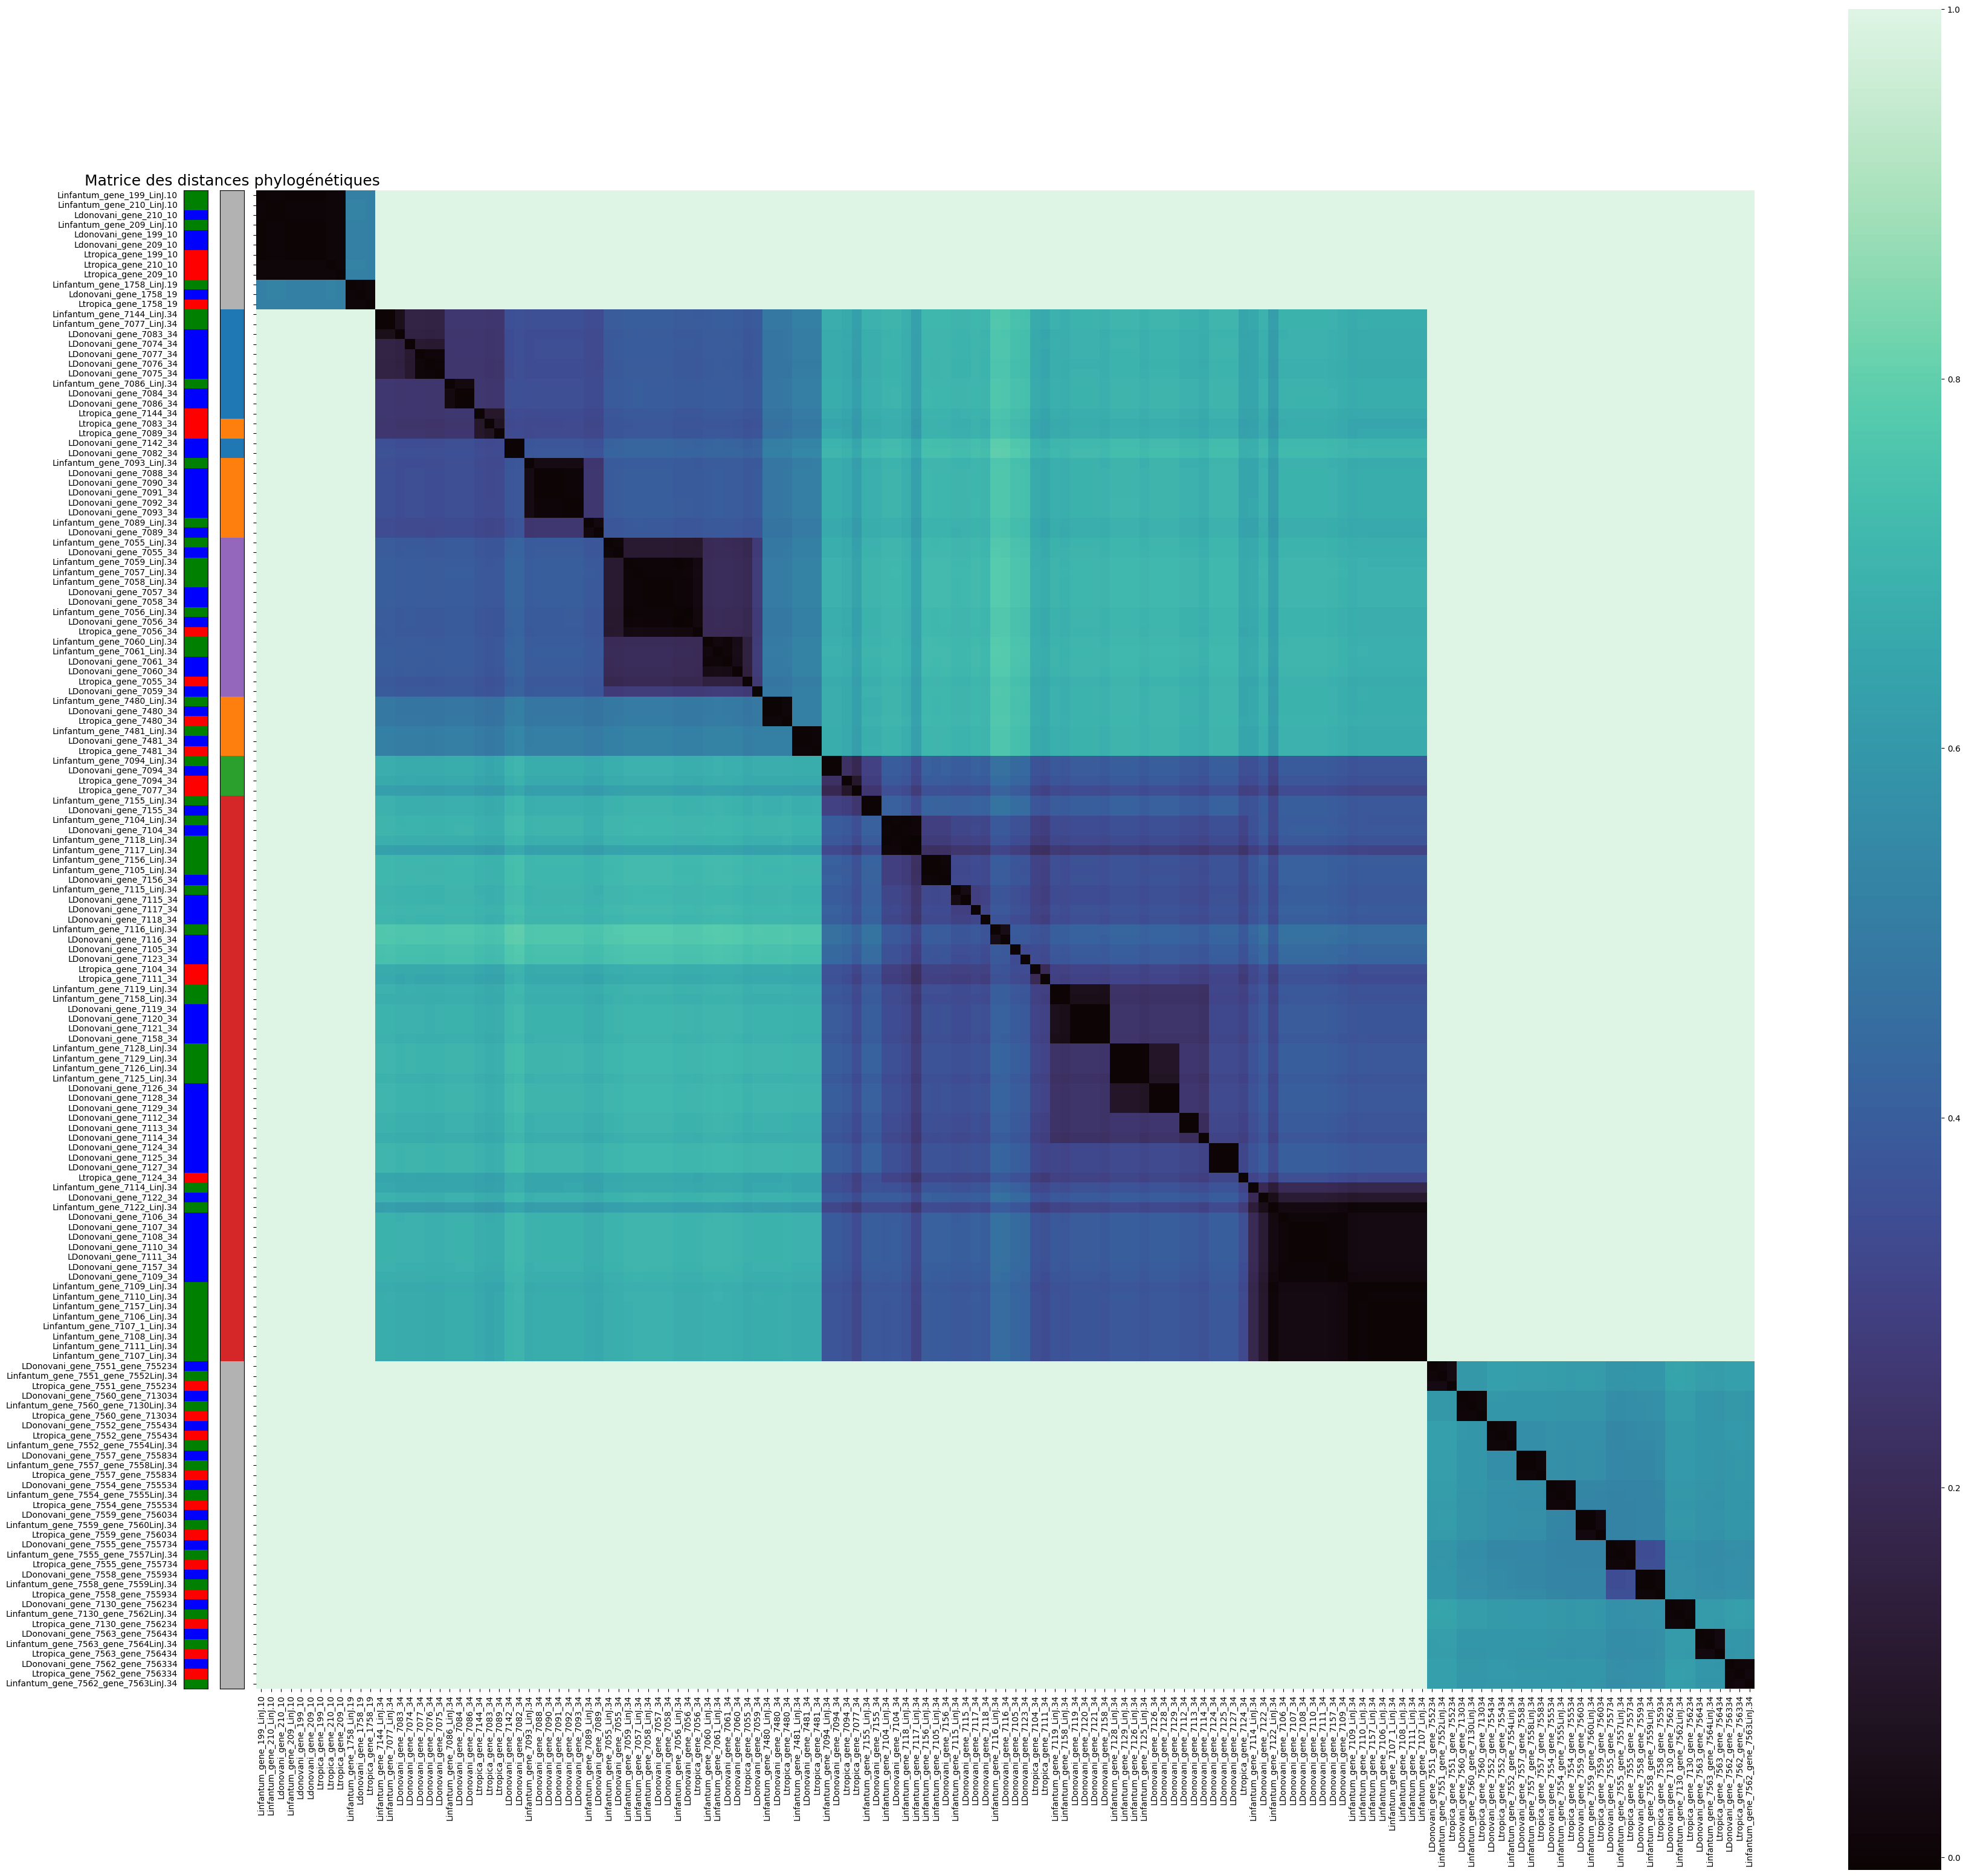

In [75]:

# Charger les trois arbres
tree1 = Phylo.read("mafft-I20250731-151358-0333-17019200-p1m.phylotree", "newick")
tree2 = Phylo.read("amestinAll.phylotree", "newick")
tree3 = Phylo.read("intergenic.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]
taxa2 = [term.name for term in tree2.get_terminals()]
taxa3 = [term.name for term in tree3.get_terminals()]

# Créer une matrice de distances complète
all_taxa = taxa1 + taxa2 + taxa3
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Distances intra-arbre 2
for i in taxa2:
    for j in taxa2:
        distance_matrix.loc[i, j] = tree2.distance(i, j)

# Distances intra-arbre 3
for i in taxa3:
    for j in taxa3:
        distance_matrix.loc[i, j] = tree3.distance(i, j)

# Distances inter-arbres : entre tree1 et tree2
for i in taxa1:
    for j in taxa2:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Distances inter-arbres : entre tree1 et tree3
for i in taxa1:
    for j in taxa3:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Distances inter-arbres : entre tree2 et tree3
for i in taxa2:
    for j in taxa3:
        distance_matrix.loc[i, j] = 1
        distance_matrix.loc[j, i] = 1

# Convertir en float
distance_matrix = distance_matrix.astype(float)



# --- Première bande couleur : ta logique existante ---
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# --- Deuxième bande couleur : basée sur resultats_color (comme avant) ---
group_map = {entry['name']: entry['group'] for entry in resultats_color}
unique_groups = sorted(set(group_map.values()))
palette = sns.color_palette("tab10", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
default_color = (0.7, 0.7, 0.7)

colors_new = []
for name in labels:
    group = group_map.get(name)
    if group:
        colors_new.append(group_colors[group])
    else:
        colors_new.append(default_color)

from matplotlib.colors import ListedColormap

# Colormap pour les deux bandes
cmap_old = ListedColormap(colors_old)
cmap_new = ListedColormap(colors_new)

plt.figure(figsize=(40, 40))
ax = sns.heatmap(distance_matrix, cmap="mako", square=True)

# Position de la heatmap pour référence
pos = ax.get_position()

# Première colonne de couleur (ton ancien groupe)
ax_colors_old = plt.gcf().add_axes([
    pos.x0 - 0.03,   # un peu plus à gauche que la heatmap
    pos.y0,
    0.01,
    pos.height
])
color_vals_old = np.arange(len(colors_old)).reshape(-1, 1)
ax_colors_old.imshow(color_vals_old, aspect='auto', cmap=cmap_old)
ax_colors_old.set_xticks([])
ax_colors_old.set_yticks([])

# Deuxième colonne de couleur (nouveau groupe)
ax_colors_new = plt.gcf().add_axes([
    pos.x0 - 0.015,  # juste à droite de la 1ère colonne couleur
    pos.y0,
    0.01,
    pos.height
])
color_vals_new = np.arange(len(colors_new)).reshape(-1, 1)
ax_colors_new.imshow(color_vals_new, aspect='auto', cmap=cmap_new)
ax_colors_new.set_xticks([])
ax_colors_new.set_yticks([])

# Ajuster labels y pour la heatmap principale
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.tick_params(axis='y', pad=90)

plt.title("Matrice des distances phylogénétiques", fontsize=18)
plt.savefig("heatmap_phylogenetique_couleurs_groupes_double.png", dpi=600, bbox_inches='tight')
plt.show()


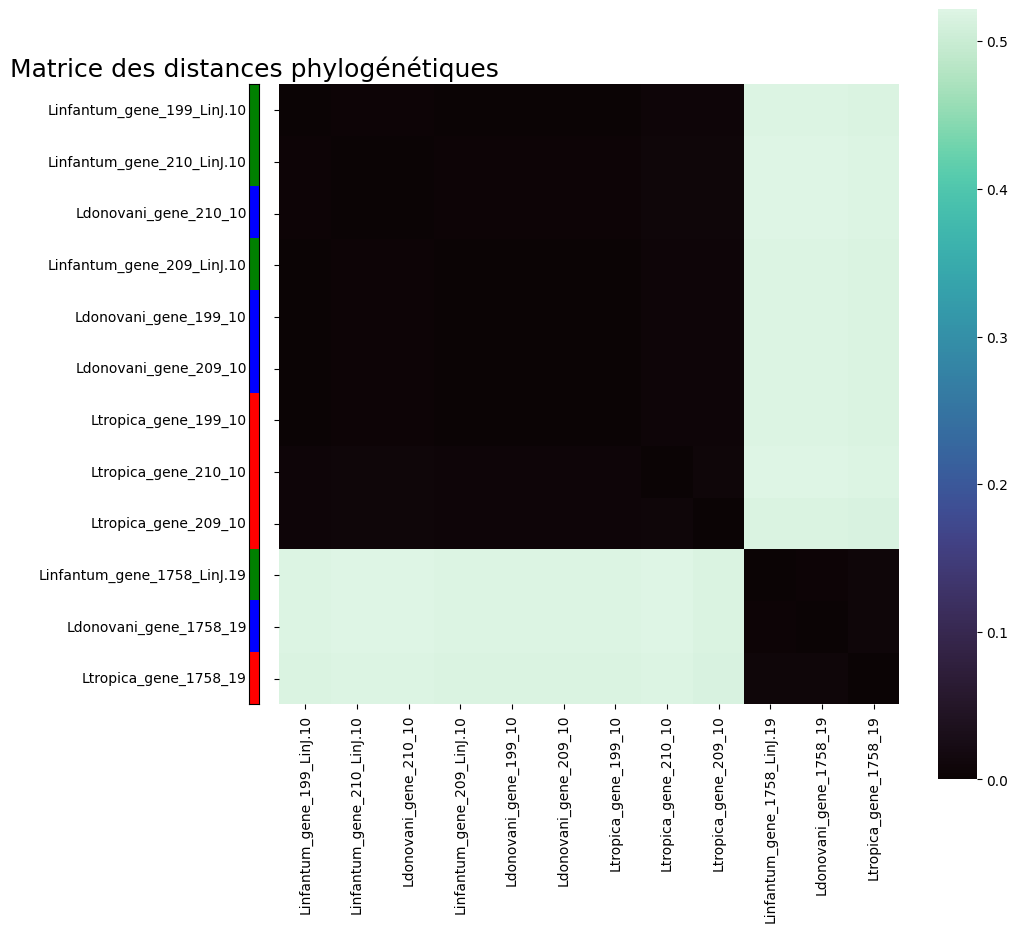

In [11]:
from Bio import Phylo

# Charger les trois arbres
tree1 = Phylo.read("mafft-I20250731-151358-0333-17019200-p1m.phylotree", "newick")


# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]


# Créer une matrice de distances complète
all_taxa = taxa1 
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Convertir en float
distance_matrix = distance_matrix.astype(float)

labels = distance_matrix.index.tolist()


# --- Première bande couleur : ta logique existante ---
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# --- Deuxième bande couleur : basée sur resultats_color (comme avant) ---


from matplotlib.colors import ListedColormap

# Colormap pour les deux bandes
cmap_old = ListedColormap(colors_old)

plt.figure(figsize=(10, 10))
ax = sns.heatmap(distance_matrix, cmap="mako", square=True)

# Position de la heatmap pour référence
pos = ax.get_position()

# Première colonne de couleur (ton ancien groupe)
ax_colors_old = plt.gcf().add_axes([
    pos.x0 - 0.03,   # un peu plus à gauche que la heatmap
    pos.y0,
    0.01,
    pos.height
])
color_vals_old = np.arange(len(colors_old)).reshape(-1, 1)
ax_colors_old.imshow(color_vals_old, aspect='auto', cmap=cmap_old)
ax_colors_old.set_xticks([])
ax_colors_old.set_yticks([])



# Ajuster labels y pour la heatmap principale
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.tick_params(axis='y', pad=20)

plt.title("Phylogenetic distance matrix Histone H3", fontsize=18)
plt.savefig("heatmap_phylogenetique_histone.png", dpi=600, bbox_inches='tight')
plt.show()


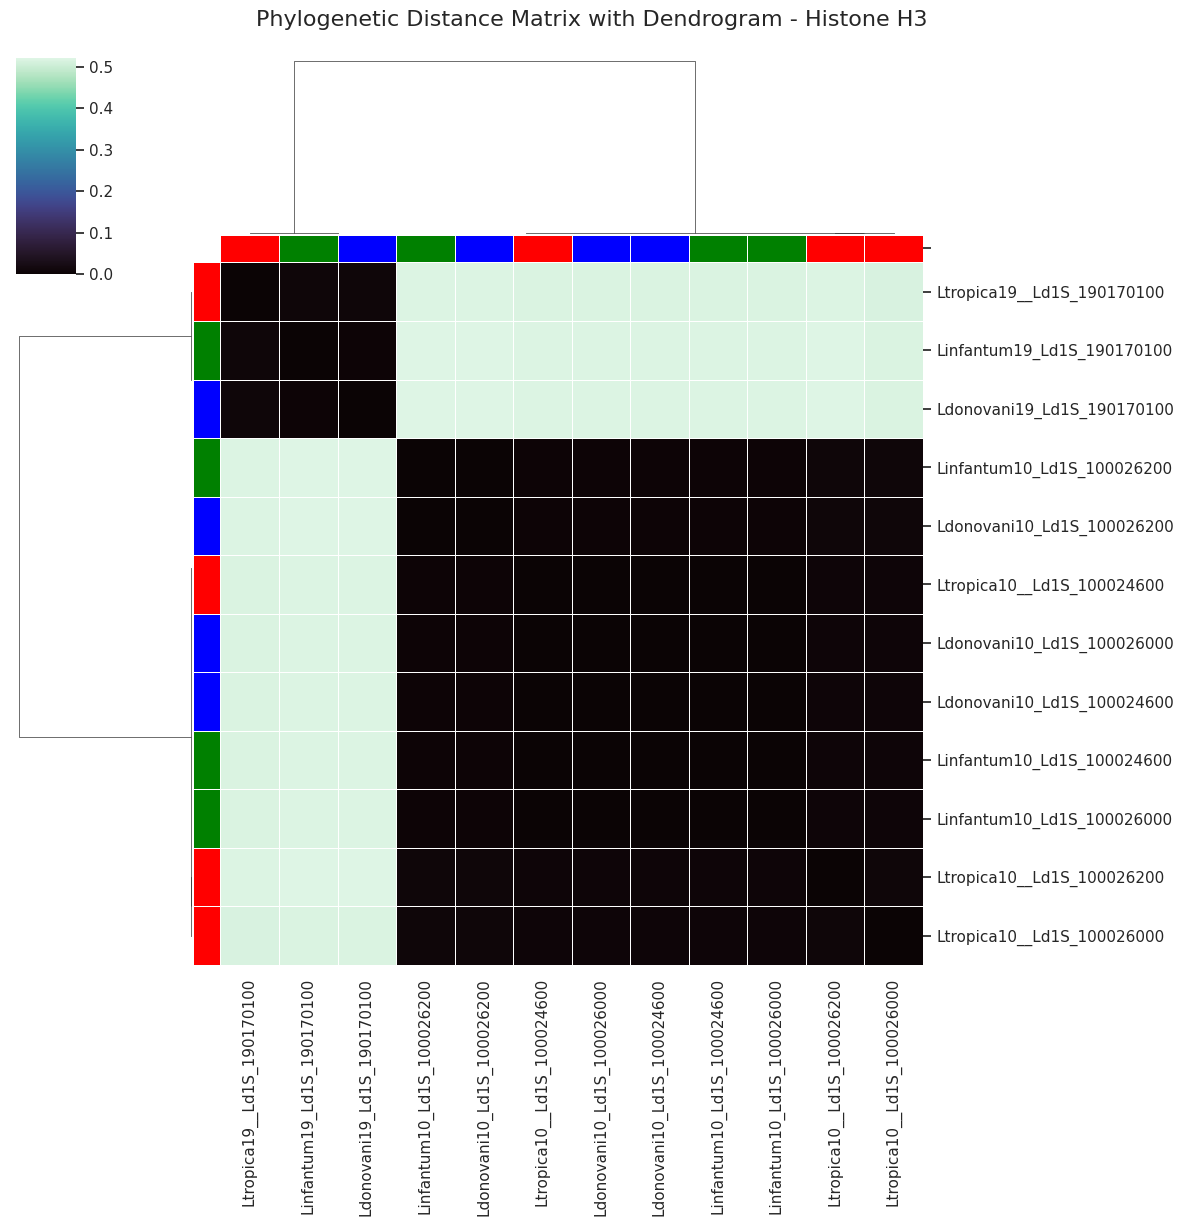

In [64]:
from Bio import Phylo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Charger l'arbre
tree1 = Phylo.read("h3.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]

# Créer la matrice de distances
all_taxa = taxa1 
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Remplir la matrice de distances
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Convertir en float
distance_matrix = distance_matrix.astype(float)

# Générer la première bande de couleur (ex: par groupe)
labels = distance_matrix.index.tolist()
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# Convertir les couleurs en objets utilisables par clustermap
row_colors = pd.Series(colors_old, index=labels)

# Afficher la clustermap avec dendrogrammes
sns.set(style="white")
g = sns.clustermap(distance_matrix, 
                   cmap="mako", 
                   row_colors=row_colors, 
                   col_colors=row_colors,
                   figsize=(12, 12),
                   linewidths=0.5)

# Ajuster le titre et sauvegarder
plt.suptitle("Phylogenetic Distance Matrix with Dendrogram - Histone H3", fontsize=16, y=1.02)
plt.savefig("heatmap_dendrogramme_histone.png", dpi=600, bbox_inches='tight')
plt.show()


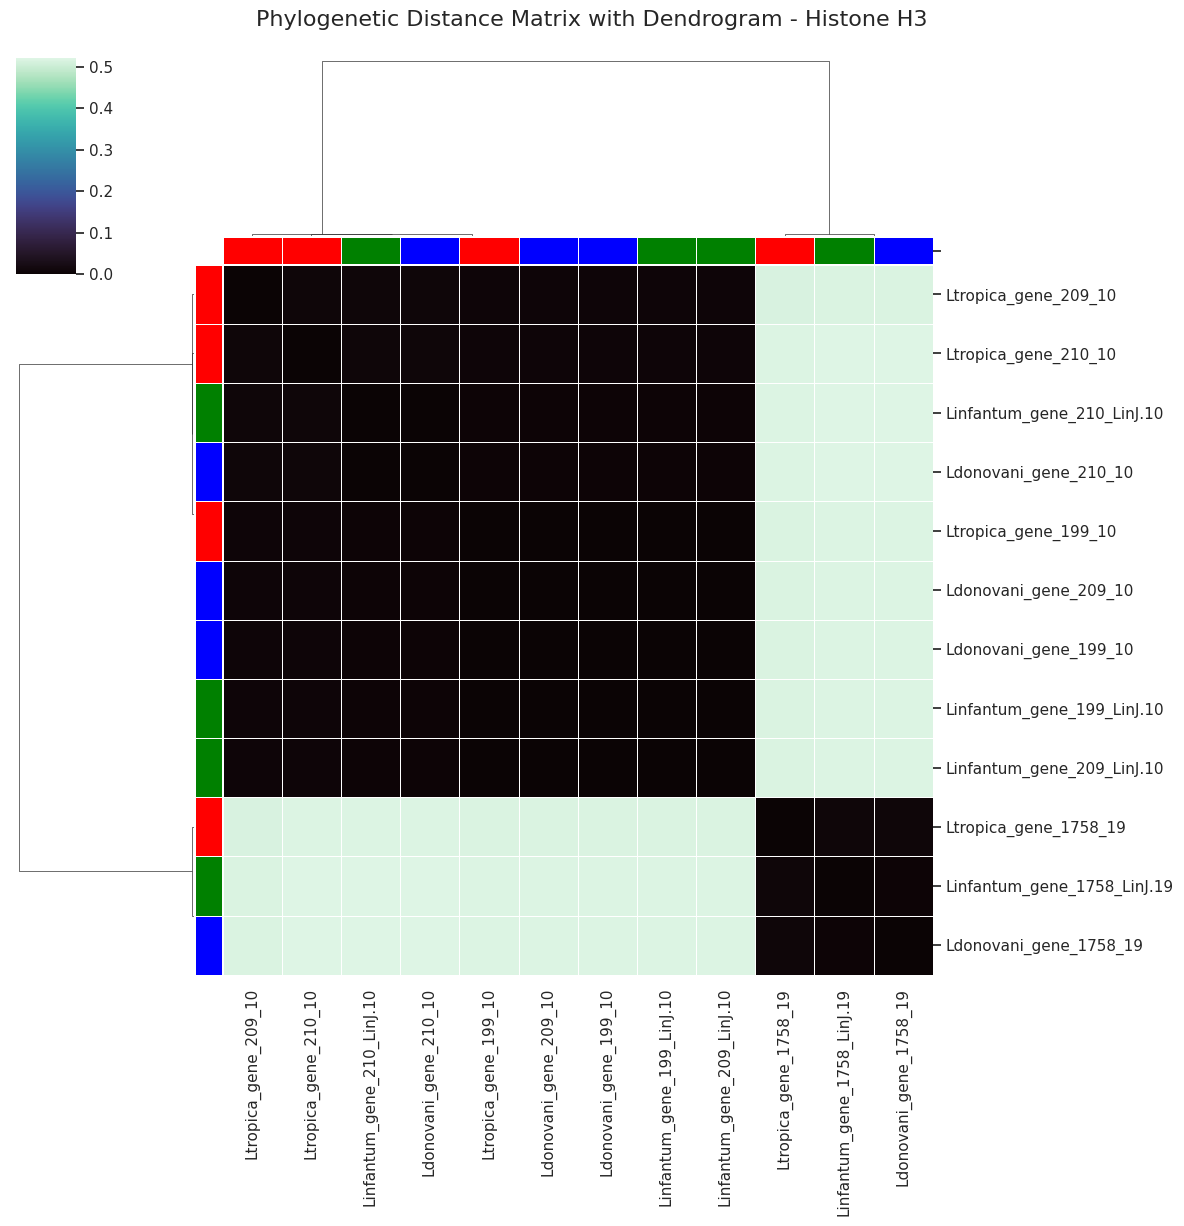

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convertir la matrice de distances carrée en format condensé
condensed_dist = squareform(distance_matrix.values)

# Calculer linkage (méthode de clustering hiérarchique)
Z = linkage(condensed_dist, method='average')  # ou 'single', 'ward', etc.

# clustermap avec linkage pré-calculé
g = sns.clustermap(distance_matrix,
                   row_linkage=Z,
                   col_linkage=Z,
                   row_colors=row_colors,
                   col_colors=row_colors,
                   cmap="mako",
                   figsize=(12, 12),
                   linewidths=0.5)

plt.suptitle("Phylogenetic Distance Matrix with Dendrogram - Histone H3", fontsize=16, y=1.02)
plt.savefig("heatmap_dendrogramme_histone.png", dpi=600, bbox_inches='tight')
plt.show()


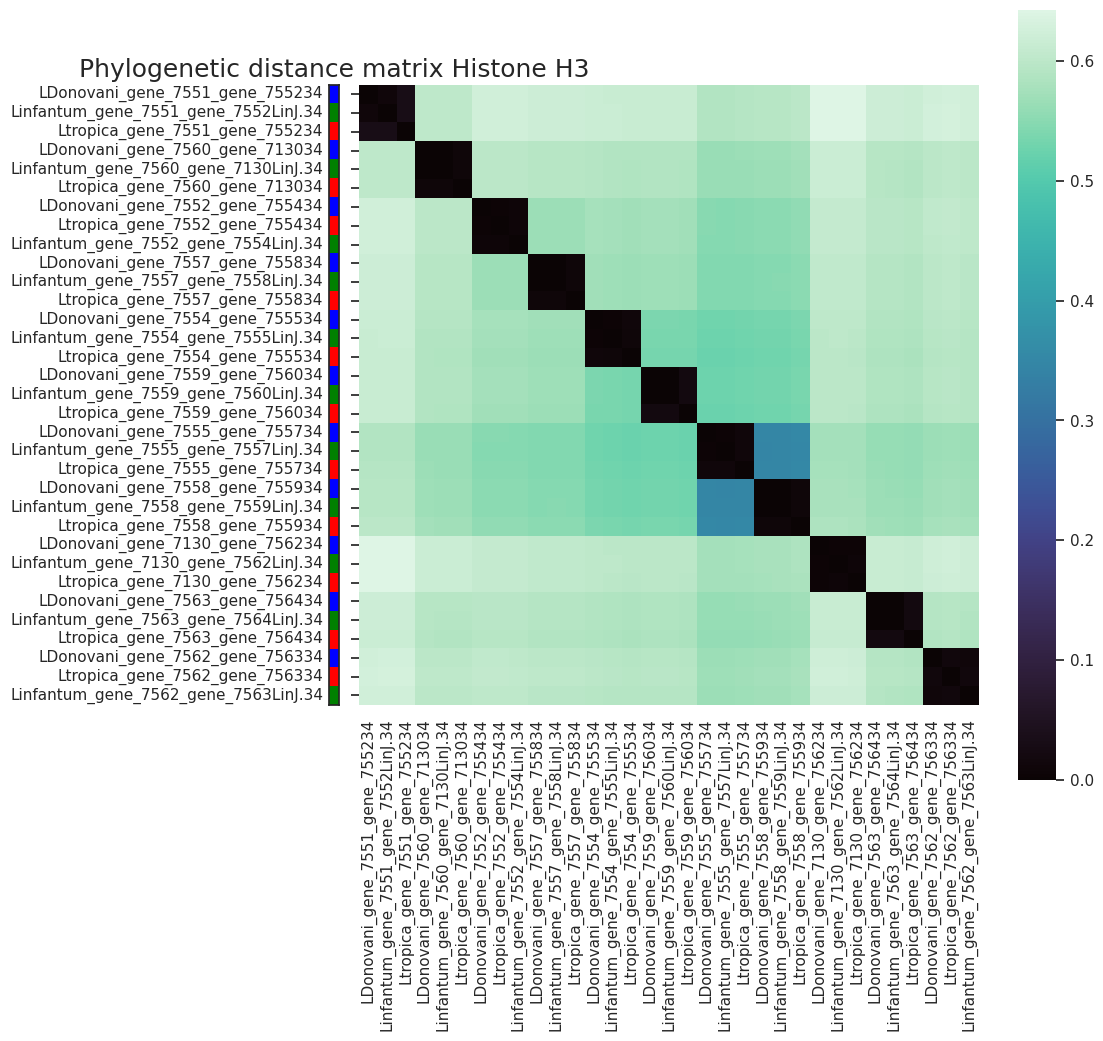

In [14]:
from Bio import Phylo

# Charger les trois arbres
tree1 = Phylo.read("intergenic.phylotree", "newick")


# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]


# Créer une matrice de distances complète
all_taxa = taxa1 
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Convertir en float
distance_matrix = distance_matrix.astype(float)

labels = distance_matrix.index.tolist()


# --- Première bande couleur : ta logique existante ---
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# --- Deuxième bande couleur : basée sur resultats_color (comme avant) ---


from matplotlib.colors import ListedColormap

# Colormap pour les deux bandes
cmap_old = ListedColormap(colors_old)

plt.figure(figsize=(10, 10))
ax = sns.heatmap(distance_matrix, cmap="mako", square=True)

# Position de la heatmap pour référence
pos = ax.get_position()

# Première colonne de couleur (ton ancien groupe)
ax_colors_old = plt.gcf().add_axes([
    pos.x0 - 0.03,   # un peu plus à gauche que la heatmap
    pos.y0,
    0.01,
    pos.height
])
color_vals_old = np.arange(len(colors_old)).reshape(-1, 1)
ax_colors_old.imshow(color_vals_old, aspect='auto', cmap=cmap_old)
ax_colors_old.set_xticks([])
ax_colors_old.set_yticks([])



# Ajuster labels y pour la heatmap principale
ax.yaxis.tick_left()
ax.yaxis.set_label_position("left")
ax.tick_params(axis='y', pad=20)

plt.title("Phylogenetic distance matrix Histone H3", fontsize=18)
plt.savefig("heatmap_phylogenetique_intergenic.png", dpi=600, bbox_inches='tight')
plt.show()


/home/parsig/miniconda3/envs/ENV1/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/home/parsig/miniconda3/envs/ENV1/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



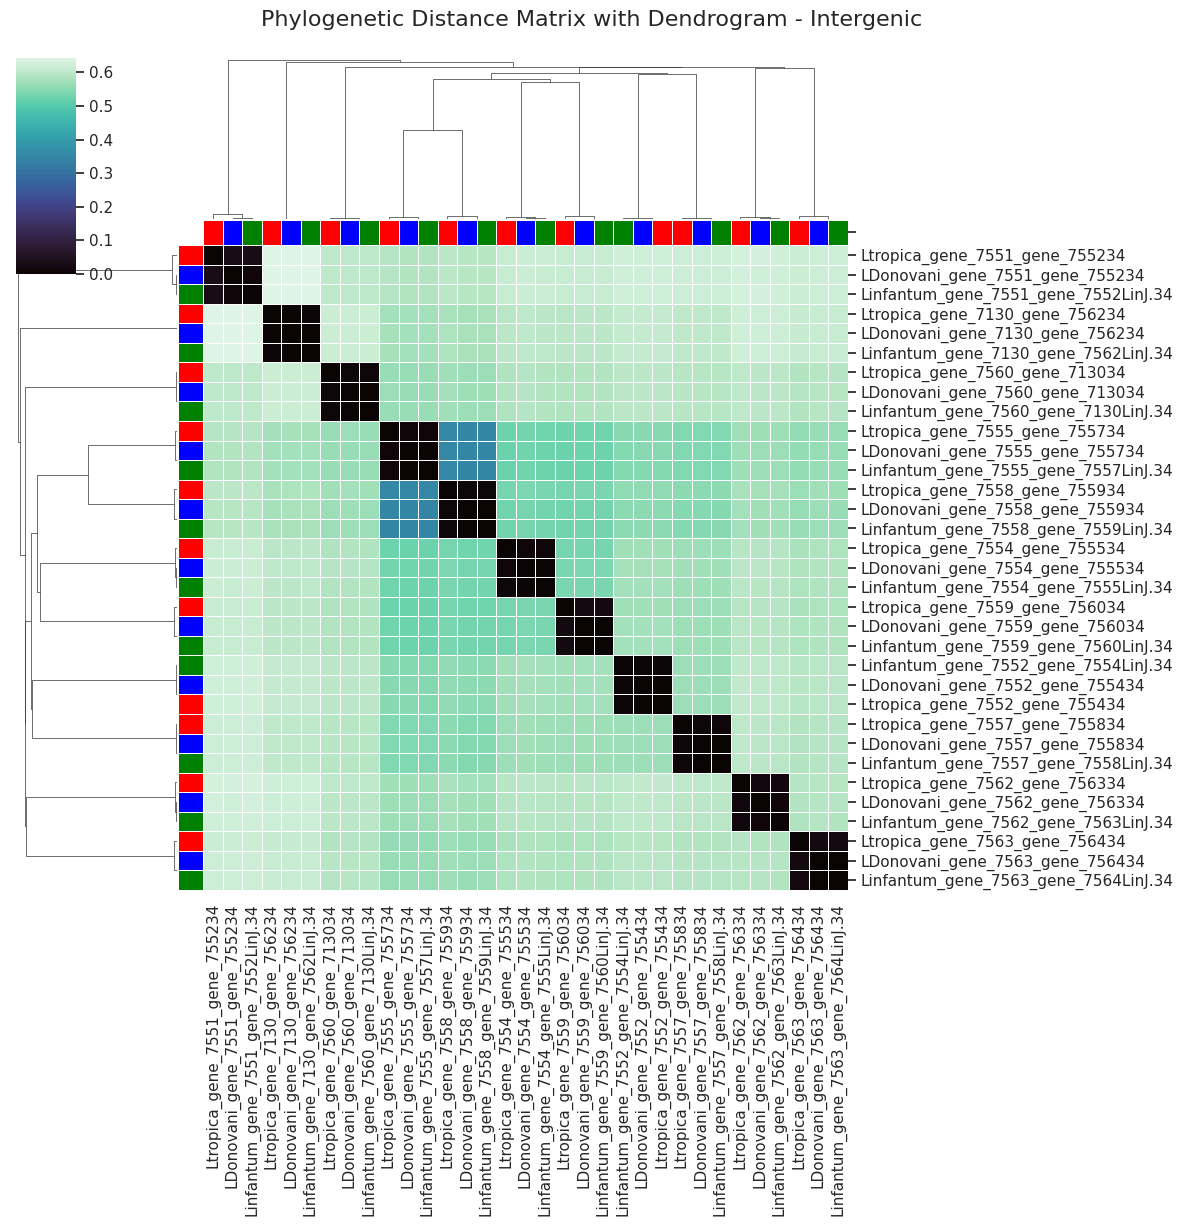

In [35]:
from Bio import Phylo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Charger l'arbre
tree1 = Phylo.read("intergenic.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]

# Créer la matrice de distances
all_taxa = taxa1 
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

# Remplir la matrice de distances
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)

# Convertir en float
distance_matrix = distance_matrix.astype(float)

# Générer la première bande de couleur (ex: par groupe)
labels = distance_matrix.index.tolist()
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# Convertir les couleurs en objets utilisables par clustermap
row_colors = pd.Series(colors_old, index=labels)

# Afficher la clustermap avec dendrogrammes
sns.set(style="white")
g = sns.clustermap(distance_matrix, 
                   cmap="mako", 
                   row_colors=row_colors, 
                   col_colors=row_colors,
                   figsize=(12, 12),
                   linewidths=0.5)

# Ajuster le titre et sauvegarder
plt.suptitle("Phylogenetic Distance Matrix with Dendrogram - Intergenic", fontsize=16, y=1.02)
plt.savefig("heatmap_dendrogramme_Intergenic.png", dpi=600, bbox_inches='tight')
plt.show()


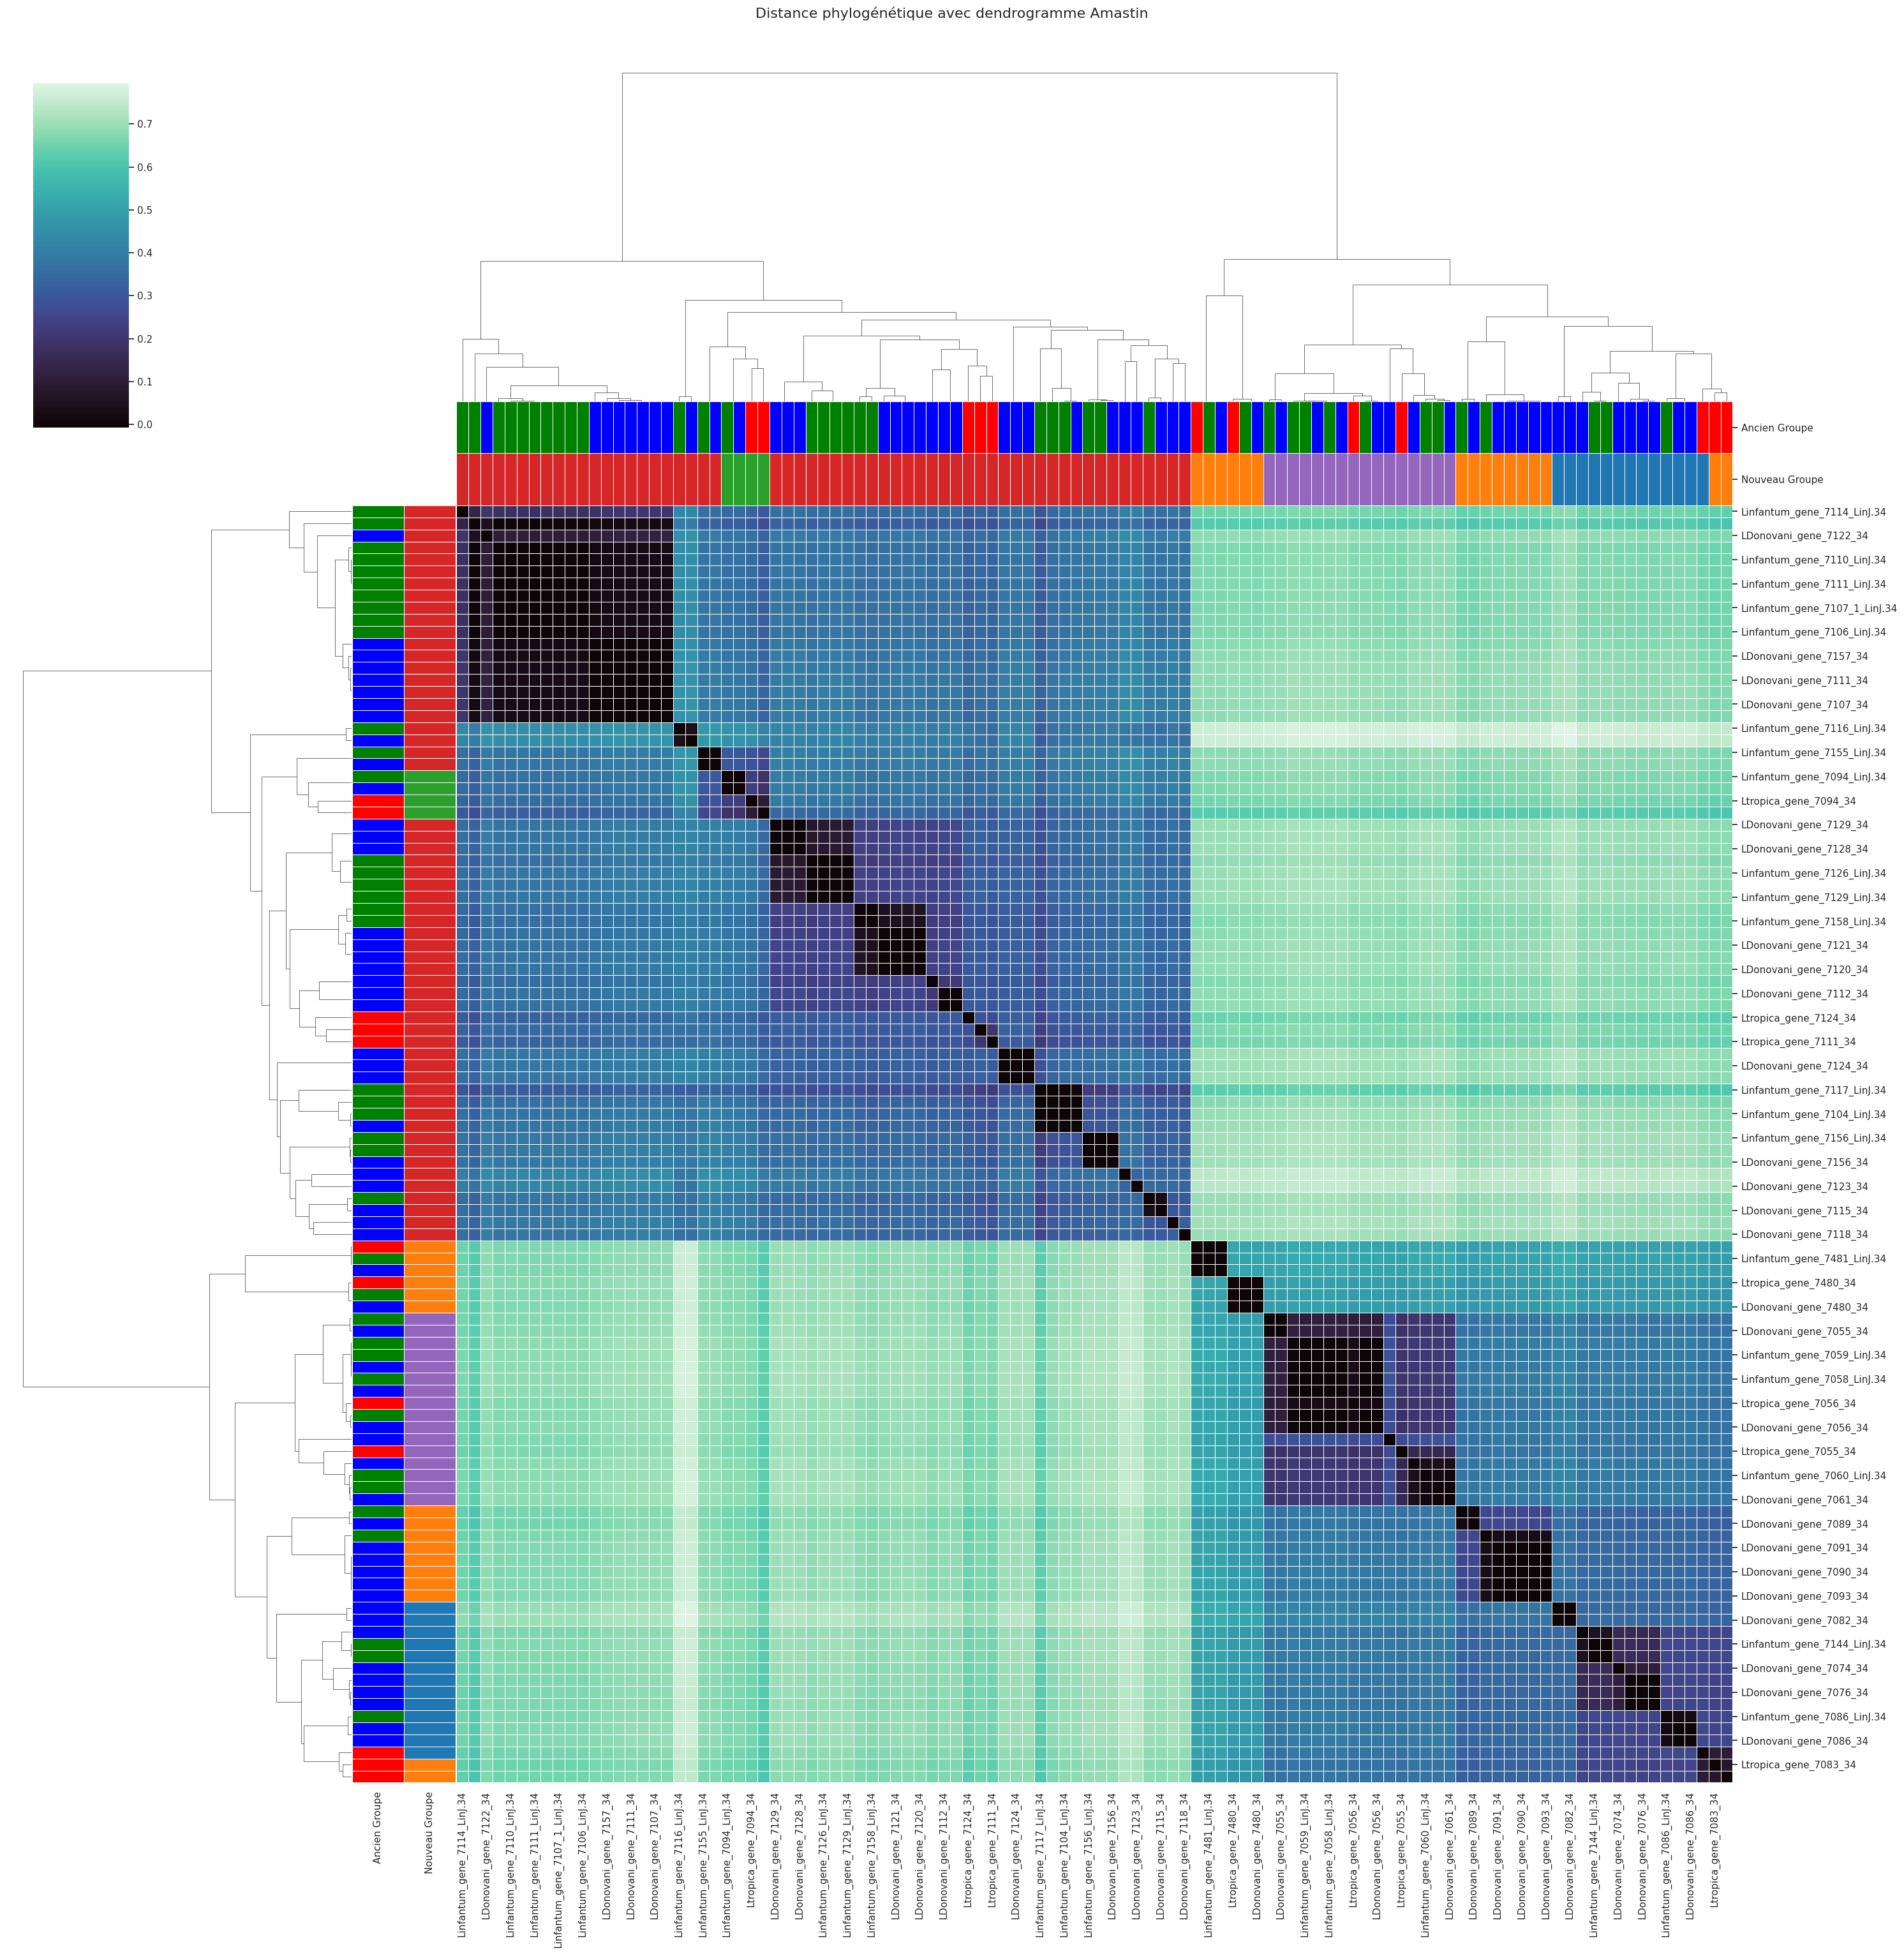

In [39]:
from Bio import Phylo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Charger l'arbre
tree1 = Phylo.read("amestinAll.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]

# Créer et remplir la matrice de distances
distance_matrix = pd.DataFrame(index=taxa1, columns=taxa1)
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)
distance_matrix = distance_matrix.astype(float)

# Labels
labels = distance_matrix.index.tolist()

# --- Première bande couleur : "ancien" groupe (par nom) ---
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# --- Deuxième bande couleur : "nouveau" groupe basé sur resultats_color ---
# Assurez-vous que `resultats_color` est une liste de dictionnaires : [{'name': '...', 'group': '...'}, ...]
group_map = {entry['name']: entry['group'] for entry in resultats_color}
unique_groups = sorted(set(group_map.values()))
palette = sns.color_palette("tab10", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
default_color = (0.7, 0.7, 0.7)

colors_new = []
for name in labels:
    group = group_map.get(name)
    if group:
        colors_new.append(group_colors[group])
    else:
        colors_new.append(default_color)

# Convertir en Series avec index pour clustermap
row_colors = pd.DataFrame({
    "Ancien Groupe": colors_old,
    "Nouveau Groupe": colors_new
}, index=labels)

# Afficher la clustermap avec les deux bandes de couleurs et dendrogrammes
sns.set(style="white")
g = sns.clustermap(distance_matrix,
                   cmap="mako",
                   row_colors=row_colors,
                   col_colors=row_colors,
                   figsize=(30, 30),
                   linewidths=0.5)

# Titre et ajustement
plt.suptitle("Distance phylogénétique avec dendrogramme Amastin", fontsize=16, y=1.02)
plt.savefig("heatmap_dendrogramme_Amastin.png", dpi=600, bbox_inches='tight')
plt.show()


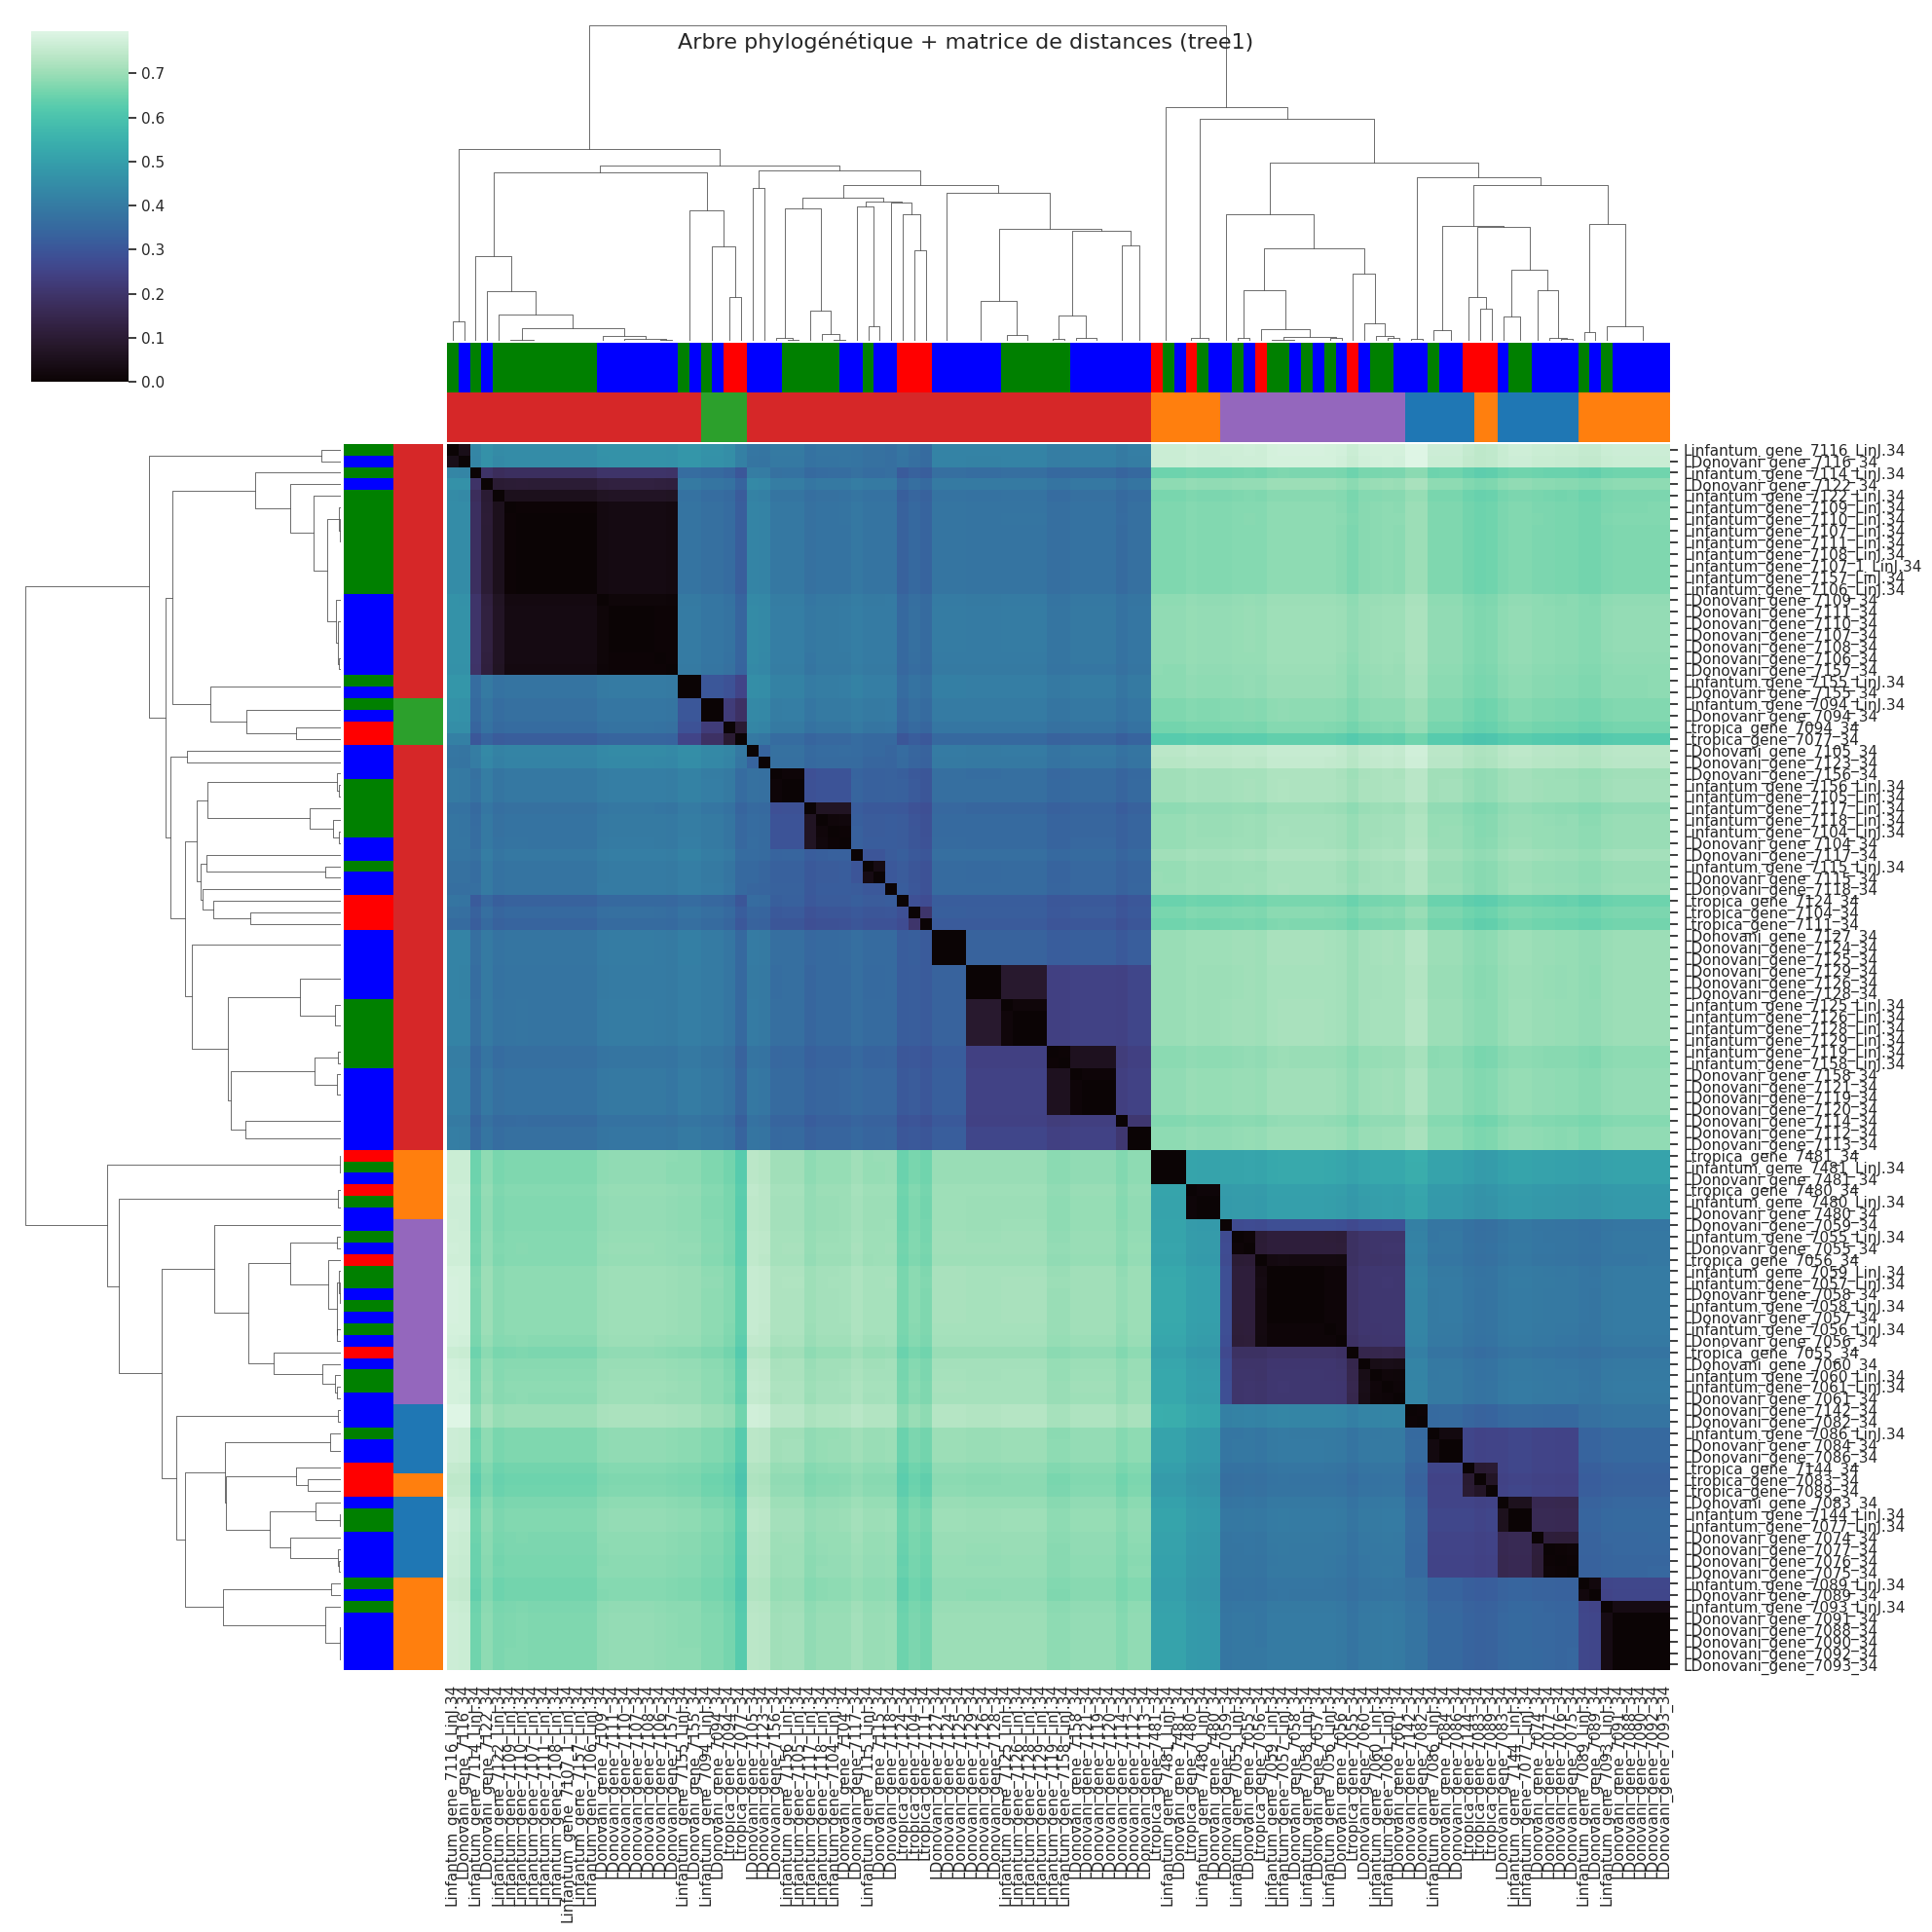

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import seaborn as sns
# Charger les trois arbres
#tree1 = Phylo.read("mafft-I20250731-151358-0333-17019200-p1m.phylotree", "newick")
#tree1 = Phylo.read("amestinAll.phylotree", "newick")


# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]

# Créer une matrice de distances complète
all_taxa = taxa1
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)

labels = distance_matrix.index.tolist()

# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)


distance_matrix = distance_matrix.astype(float)

# --- Première bande couleur : ta logique existante ---
colors_old = []
for name in labels:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# --- Deuxième bande couleur : basée sur resultats_color (comme avant) ---
group_map = {entry['name']: entry['group'] for entry in resultats_color}
unique_groups = sorted(set(group_map.values()))
palette = sns.color_palette("tab10", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
default_color = (0.7, 0.7, 0.7)

colors_new = []
for name in labels:
    group = group_map.get(name)
    if group:
        colors_new.append(group_colors[group])
    else:
        colors_new.append(default_color)

# Créer matrice de distance pour tree1 uniquement
submatrix = distance_matrix.loc[taxa1, taxa1]

# Conversion pour linkage (elle doit être vectorisée et symétrique)
linkage_matrix = linkage(squareform(submatrix), method='average')

# Réordonner selon clustering
sns.set(style="white")

# Ajouter les mêmes couleurs que plus haut (old / new) :
colors_old_tree1 = [colors_old[labels.index(t)] for t in taxa1]
colors_new_tree1 = [colors_new[labels.index(t)] for t in taxa1]

# Créer le clustermap
g = sns.clustermap(
    submatrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    row_colors=[colors_old_tree1, colors_new_tree1],
    col_colors=[colors_old_tree1, colors_new_tree1],
    cmap="mako",
    figsize=(20, 20),
    xticklabels=True,
    yticklabels=True
)

# Titre
plt.suptitle("Arbre phylogénétique + matrice de distances (tree1)", fontsize=16)

# Sauvegarde
g.savefig("clustermap_phylogenetique_tests.png", dpi=600)
plt.show()


In [18]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Sous-matrice propre : seulement tree1
taxa = taxa1
submatrix = distance_matrix.loc[taxa, taxa]

# Remplir la diagonale avec une petite valeur pour éviter les 0 exacts
np.fill_diagonal(submatrix.values, 1e-10)

# Convertir en vecteur de distances avec squareform
condensed = squareform(submatrix)

# Vérifier qu’il n’y a pas de valeurs négatives
if np.any(condensed < 0):
    raise ValueError("Distances négatives détectées dans la sous-matrice.")

# Créer la linkage matrix
linkage_matrix = linkage(condensed, method='average')

# Préparer les couleurs associées
colors_old_tree1 = [colors_old[labels.index(t)] for t in taxa]
colors_new_tree1 = [colors_new[labels.index(t)] for t in taxa]

# Afficher avec clustermap
g = sns.clustermap(
    submatrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    row_colors=[colors_old_tree1, colors_new_tree1],
    col_colors=[colors_old_tree1, colors_new_tree1],
    cmap="mako",
    figsize=(20, 20),
    xticklabels=True,
    yticklabels=True
)

plt.suptitle("Arbre phylogénétique + matrice de distances (tree1)", fontsize=16)
g.savefig("clustermap_phylogenetique_tree1_test.png", dpi=600)
plt.show()


ValueError: Distance matrix 'X' diagonal must be zero.

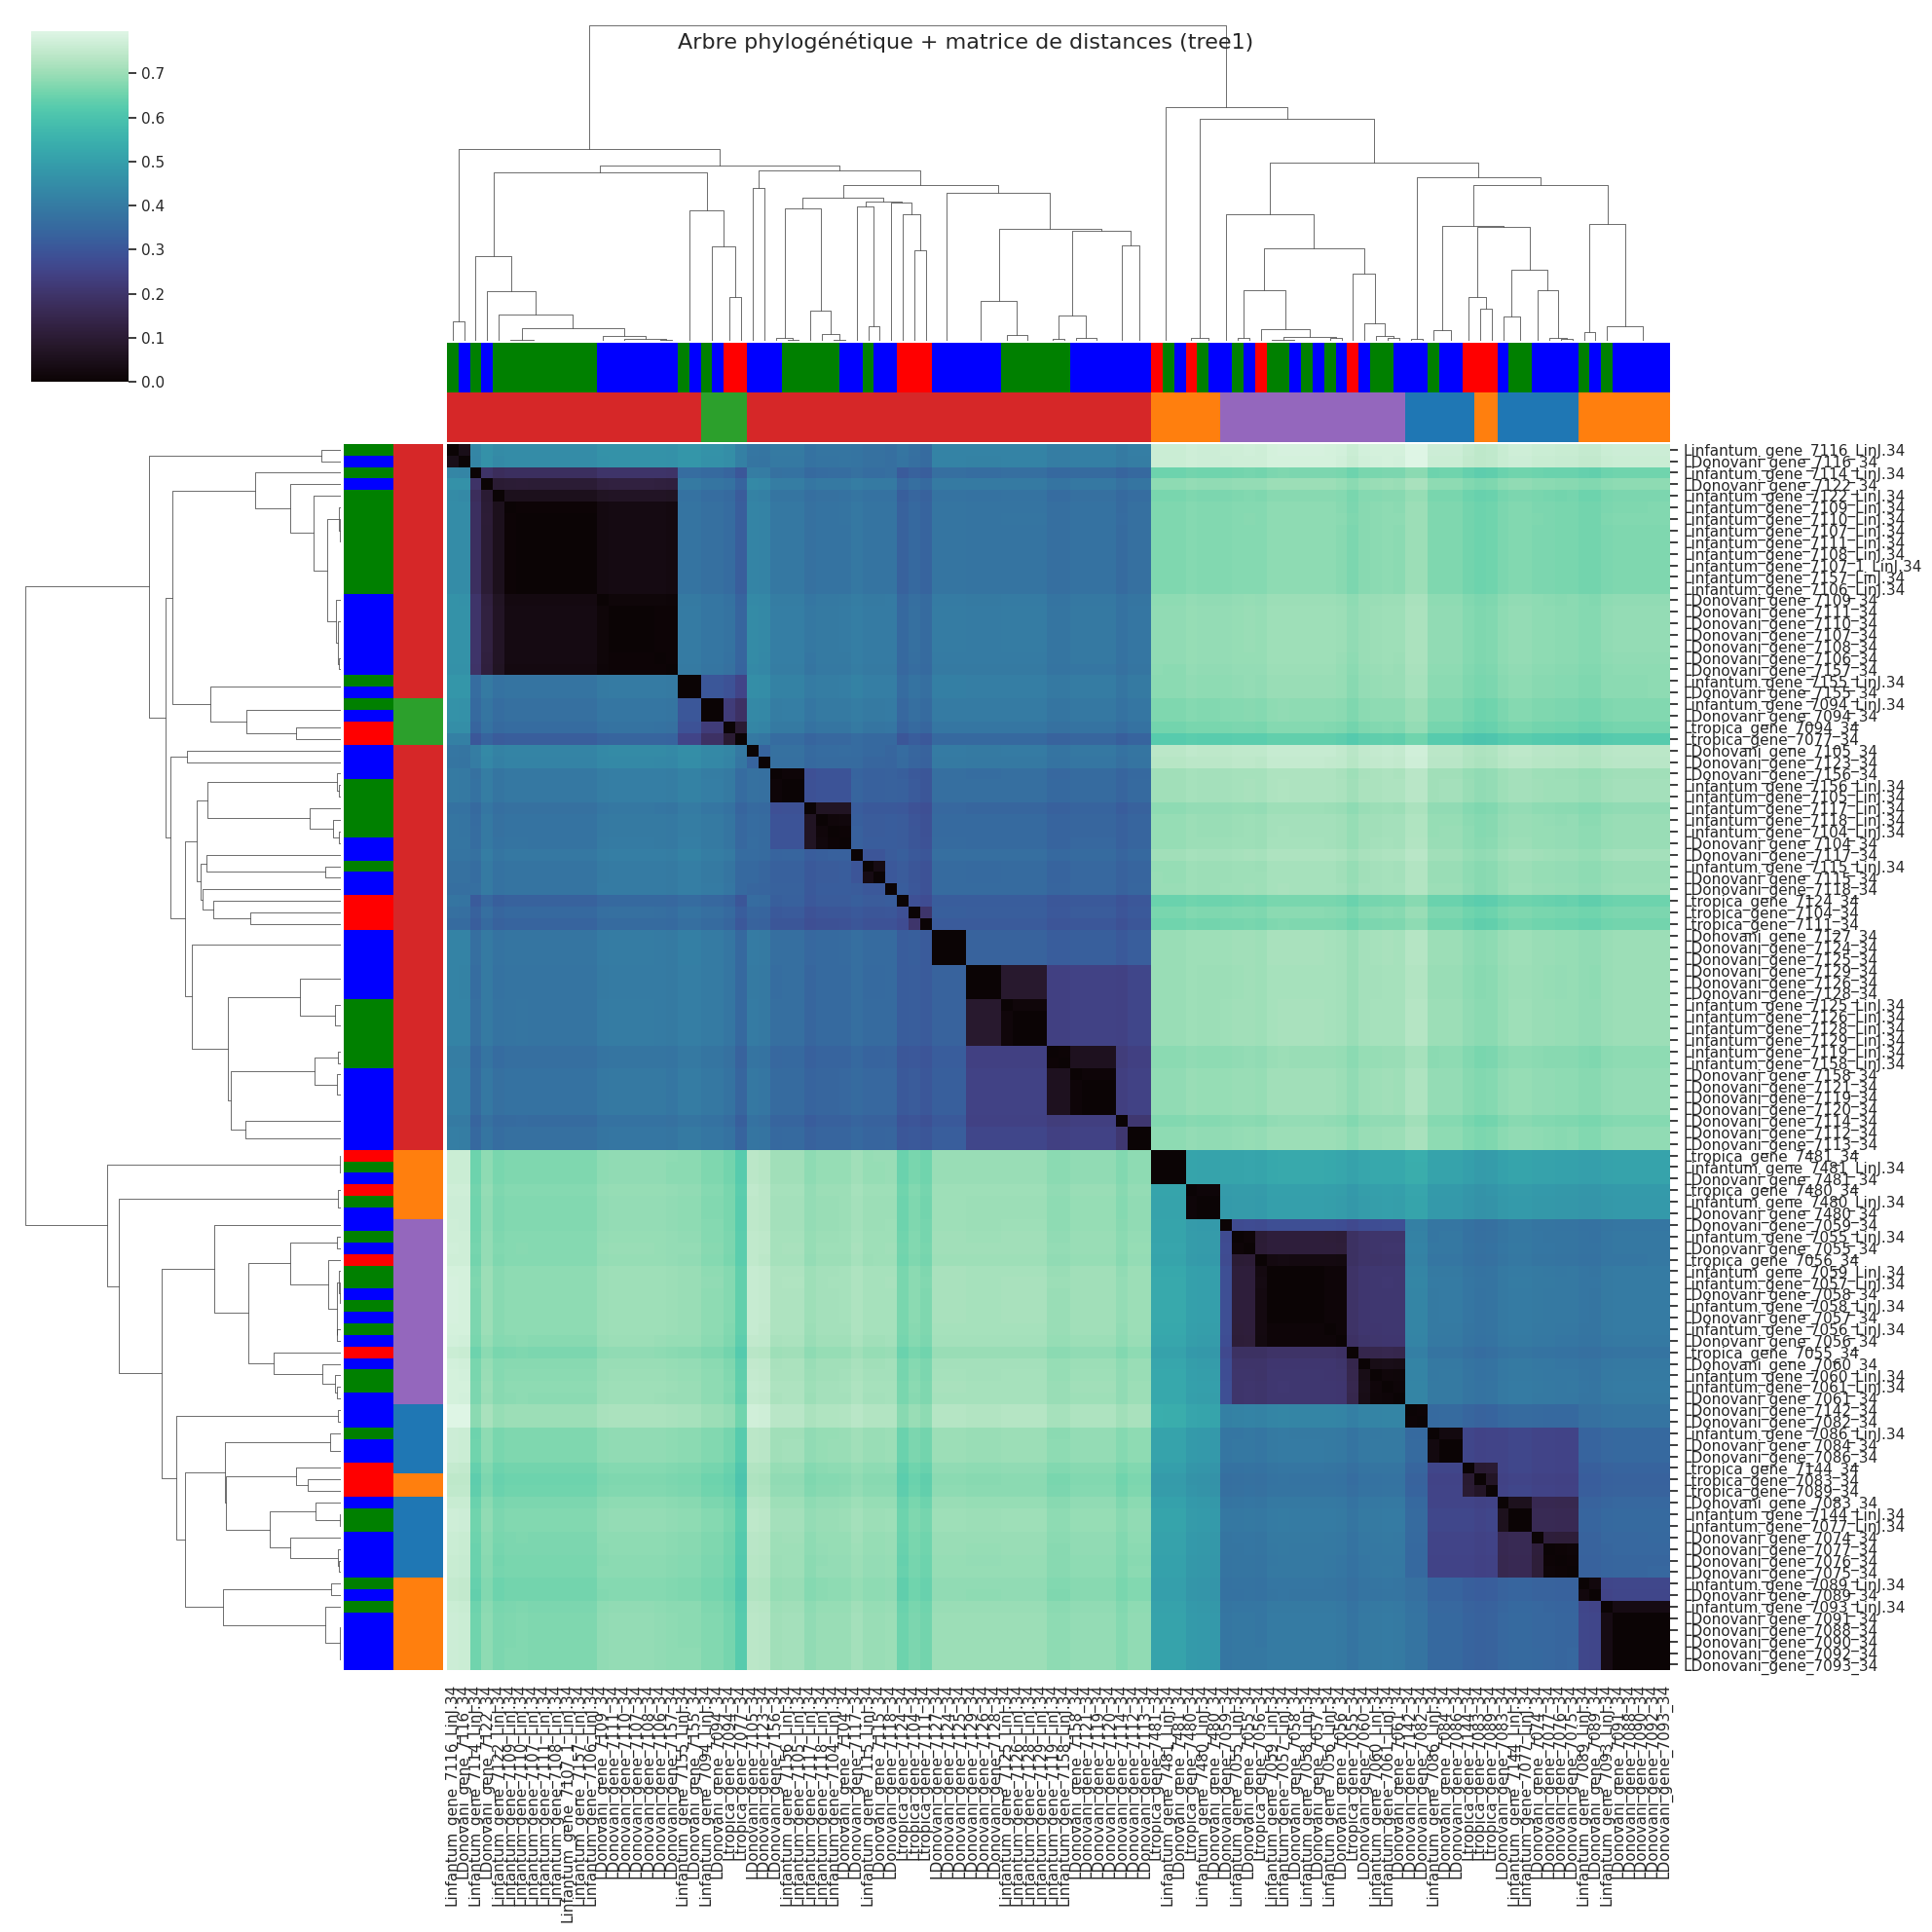

In [19]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Sous-matrice propre (tree1 uniquement)
taxa = taxa1
submatrix = distance_matrix.loc[taxa, taxa].copy()

# Vérification : diagonale = 0
np.fill_diagonal(submatrix.values, 0.0)

# Vérification de symétrie (bonne pratique)
assert np.allclose(submatrix, submatrix.T), "Matrice non symétrique"

# Vérifier qu’il n’y a pas de valeurs négatives (hors diagonale)
if (submatrix.values[np.triu_indices_from(submatrix, 1)] < 0).any():
    raise ValueError("Distances négatives détectées")

# Convertir en vecteur de distances
condensed = squareform(submatrix.values)

# Créer la linkage matrix
linkage_matrix = linkage(condensed, method='average')

# Couleurs
colors_old_tree1 = [colors_old[labels.index(t)] for t in taxa]
colors_new_tree1 = [colors_new[labels.index(t)] for t in taxa]

# Affichage avec clustermap
g = sns.clustermap(
    submatrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    row_colors=[colors_old_tree1, colors_new_tree1],
    col_colors=[colors_old_tree1, colors_new_tree1],
    cmap="mako",
    figsize=(20, 20),
    xticklabels=True,
    yticklabels=True
)

plt.suptitle("Arbre phylogénétique + matrice de distances (tree1)", fontsize=16)
g.savefig("clustermap_phylogenetique_tree1_test.png", dpi=600)
plt.show()


In [23]:
def fix_negative_branches_abs(tree):
    for clade in tree.find_clades():
        if clade.branch_length is not None and clade.branch_length < 0:
            print(f"Corrigé: {clade.name}, de {clade.branch_length} à {abs(clade.branch_length)}")
            clade.branch_length = abs(clade.branch_length)
    return tree
tree1 = fix_negative_branches_abs(tree1)


Corrigé: Linfantum_gene_7144_LinJ.34, de -0.0002 à 0.0002
Corrigé: LDonovani_gene_7142_34, de -0.00289 à 0.00289
Corrigé: Linfantum_gene_7056_LinJ.34, de -0.0039 à 0.0039
Corrigé: LDonovani_gene_7056_34, de -0.00197 à 0.00197
Corrigé: Linfantum_gene_7118_LinJ.34, de -0.00736 à 0.00736
Corrigé: Linfantum_gene_7117_LinJ.34, de -0.02936 à 0.02936
Corrigé: Linfantum_gene_7105_LinJ.34, de -0.00123 à 0.00123
Corrigé: Linfantum_gene_7158_LinJ.34, de -0.0029 à 0.0029
Corrigé: LDonovani_gene_7158_34, de -0.00347 à 0.00347
Corrigé: Linfantum_gene_7125_LinJ.34, de -0.0065 à 0.0065
Corrigé: Linfantum_gene_7122_LinJ.34, de -0.02245 à 0.02245
Corrigé: LDonovani_gene_7109_34, de -0.00436 à 0.00436
Corrigé: Linfantum_gene_7109_LinJ.34, de -0.00186 à 0.00186


Corrigé: Linfantum_gene_7144_LinJ.34, de -0.0002 à 0.0002
Corrigé: LDonovani_gene_7142_34, de -0.00289 à 0.00289
Corrigé: Linfantum_gene_7056_LinJ.34, de -0.0039 à 0.0039
Corrigé: LDonovani_gene_7056_34, de -0.00197 à 0.00197
Corrigé: Linfantum_gene_7118_LinJ.34, de -0.00736 à 0.00736
Corrigé: Linfantum_gene_7117_LinJ.34, de -0.02936 à 0.02936
Corrigé: Linfantum_gene_7105_LinJ.34, de -0.00123 à 0.00123
Corrigé: Linfantum_gene_7158_LinJ.34, de -0.0029 à 0.0029
Corrigé: LDonovani_gene_7158_34, de -0.00347 à 0.00347
Corrigé: Linfantum_gene_7125_LinJ.34, de -0.0065 à 0.0065
Corrigé: Linfantum_gene_7122_LinJ.34, de -0.02245 à 0.02245
Corrigé: LDonovani_gene_7109_34, de -0.00436 à 0.00436
Corrigé: Linfantum_gene_7109_LinJ.34, de -0.00186 à 0.00186


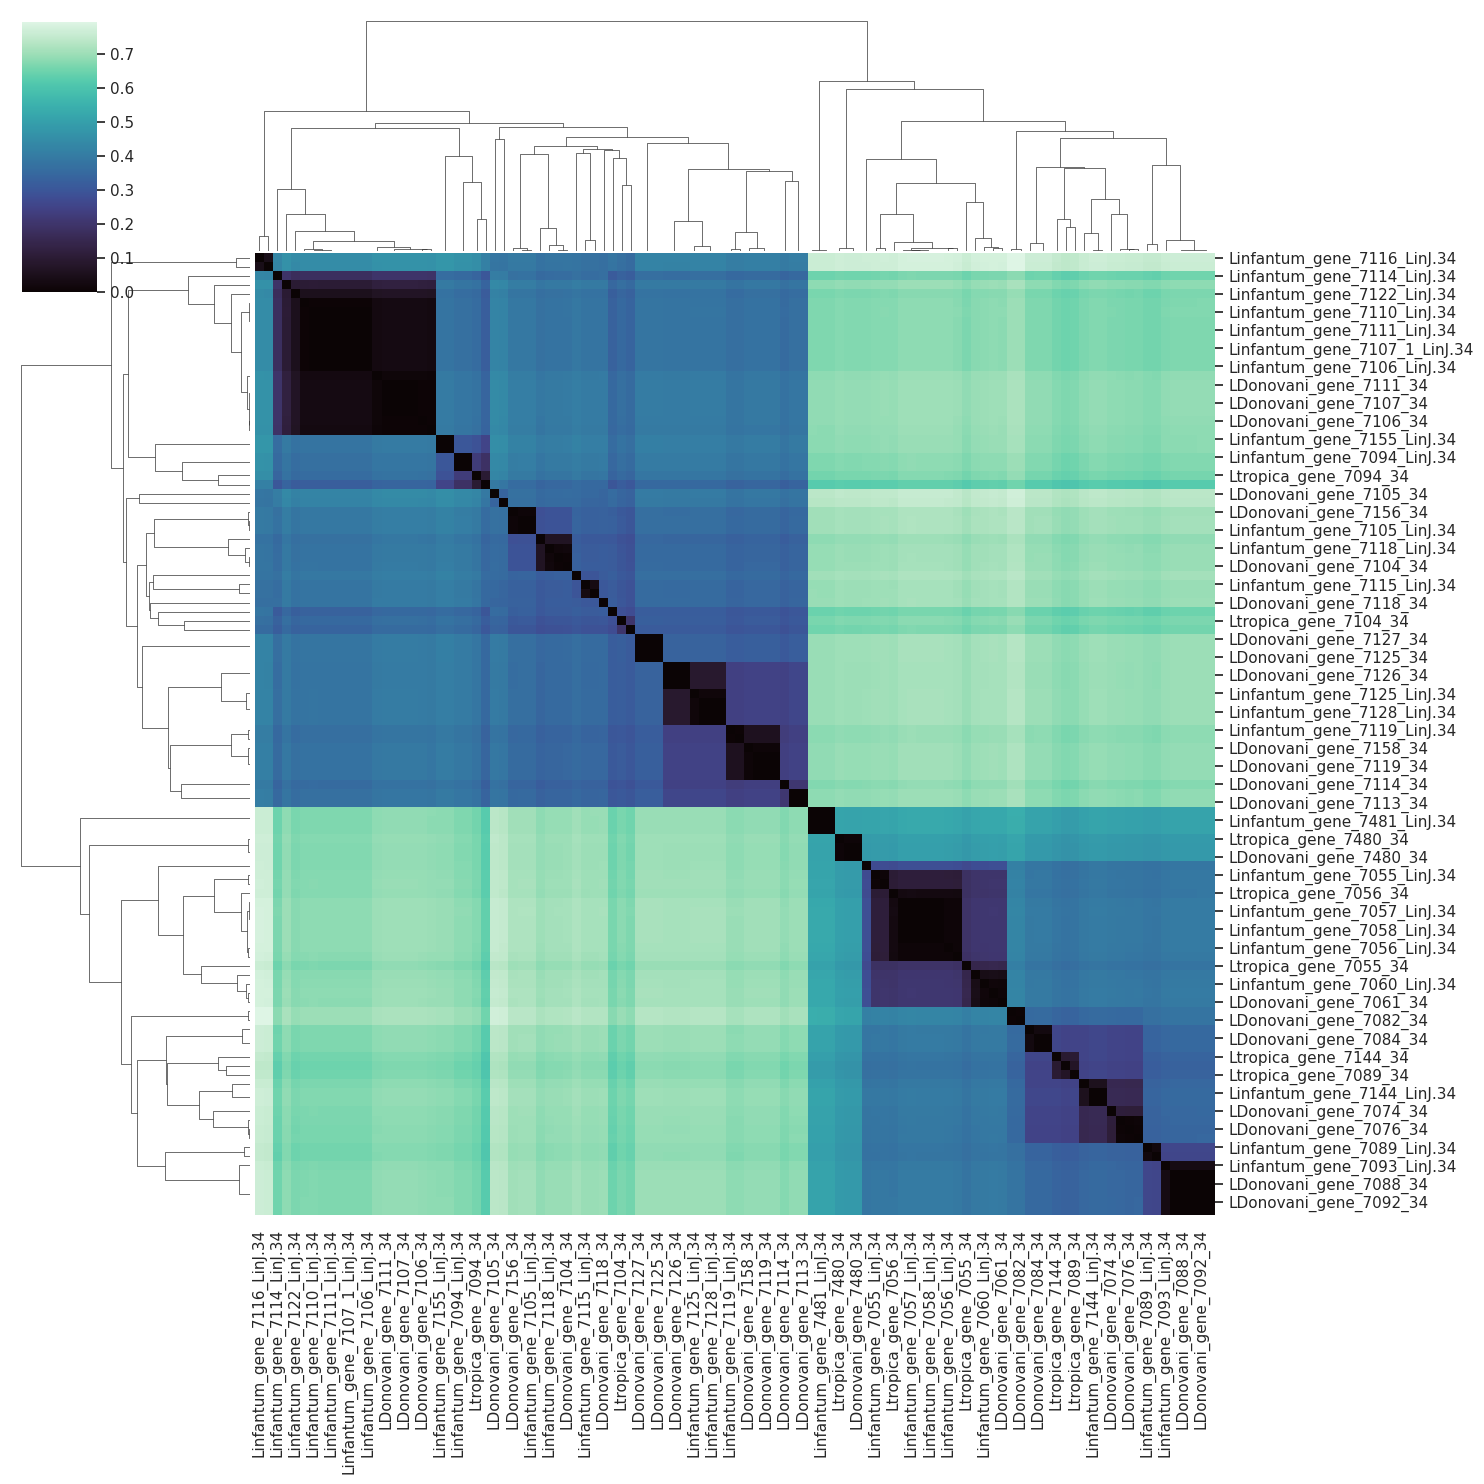

In [35]:
from Bio import Phylo
import numpy as np
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

# 1) Charger l'arbre
tree = Phylo.read("amestinAll.phylotree", "newick")
tree = fix_negative_branches_abs(tree)
# 2) Extraire les noms des feuilles
taxa = [term.name for term in tree.get_terminals()]

# 3) Calculer la matrice des distances entre feuilles selon l'arbre
dist_matrix = np.zeros((len(taxa), len(taxa)))
for i, t1 in enumerate(taxa):
    for j, t2 in enumerate(taxa):
        dist_matrix[i, j] = tree.distance(t1, t2)

# 4) Convertir en matrice de distances condensée (format scipy)
dist_condensed = squareform(dist_matrix)

# 5) Créer linkage à partir de la matrice de distances
Z = linkage(dist_condensed, method='average')  # ou 'single', 'complete' selon l'arbre

# 6) Utiliser dans seaborn.clustermap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(dist_matrix, index=taxa, columns=taxa)

sns.clustermap(df,
               row_linkage=Z,
               col_linkage=Z,
               row_cluster=True,
               col_cluster=True,
               cmap='mako',
               figsize=(15, 15))
plt.show()


In [12]:
import seaborn as sns
import matplotlib

# Choisir la palette seaborn
palette = sns.color_palette("tab10", 10)  # 10 couleurs max

# Convertir chaque couleur (r,g,b floats 0-1) en hex string
hex_colors = [matplotlib.colors.rgb2hex(c) for c in palette]

print(hex_colors)
# Exemple de sortie: ['#1f77b4', '#ff7f0e', '#2ca02c', ...]


with open("itol_heatmap.txt", "w") as f:
    f.write("DATASET_HEATMAP\n")
    f.write("SEPARATOR TAB\n")
    f.write("DATASET_LABEL\tDistance matrix\n")
    f.write("COLOR\t#ff0000\n")  # couleur par défaut (une vraie couleur)
    f.write("COLOR_SPECTRUM\t#0000FF,#FF0000\n")  # bleu → rouge
    f.write("FIELD_LABELS\t" + "\t".join(distance_matrix.columns) + "\n")
    f.write("FIELD_COLORS\t" + "\t".join(hex_colors[:len(distance_matrix.columns)]) + "\n")
    f.write("DATA\n")
    
    for taxon in distance_matrix.index:
        values = "\t".join(f"{distance_matrix.loc[taxon, col]:.3f}" for col in distance_matrix.columns)
        f.write(f"{taxon}\t{values}\n")


['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


Palette mako hex: ['#332345', '#40498e', '#357ba3', '#38aaac', '#79d6ae']


Palette iTOL: ['#322244', '#347aa2', '#79d5ae']


In [58]:
import seaborn as sns

palette = sns.color_palette("mako", 5)
# Choisir le min, mid et max dans ta palette
import seaborn as sns
from matplotlib.colors import rgb2hex

palette = sns.color_palette("mako", 3)
color_min = rgb2hex(palette[0])
color_mid = rgb2hex(palette[1])
color_max = rgb2hex(palette[2])

print(color_min, color_mid, color_max)


tree1 = Phylo.read("amestinAll_2.phylotree", "newick")

# Obtenir les noms des taxons
taxa1 = [term.name for term in tree1.get_terminals()]

# Créer une matrice de distances complète
all_taxa = taxa1 
distance_matrix = pd.DataFrame(index=all_taxa, columns=all_taxa)
distance_matrix = distance_matrix.loc[taxa1, taxa1]  # réordonner lignes et colonnes selon taxa1
# Distances intra-arbre 1
for i in taxa1:
    for j in taxa1:
        distance_matrix.loc[i, j] = tree1.distance(i, j)


with open("itol_heatmap.txt", "w") as f:
    f.write("DATASET_HEATMAP\n")
    f.write("SEPARATOR TAB\n")
    f.write("DATASET_LABEL\tDistance matrix\n")
    f.write(f"COLOR_MIN\t{color_min}\n")
    f.write(f"COLOR_MID\t{color_mid}\n")
    f.write(f"COLOR_MAX\t{color_max}\n")
    f.write("FIELD_LABELS\t" + "\t".join(distance_matrix.columns) + "\n")
    f.write("DATA\n")
    for taxon in distance_matrix.index:
        values = "\t".join(f"{distance_matrix.loc[taxon, col]:.3f}" for col in distance_matrix.columns)
        f.write(f"{taxon}\t{values}\n")


#3e356b #357ba3 #4bc2ad


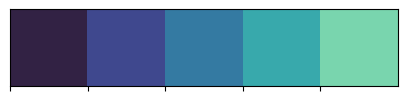

In [20]:
palette = sns.color_palette("mako", 5)
sns.palplot(palette)


In [24]:
print("Index (rows) order:", distance_matrix.index.tolist())
print("Columns order:", distance_matrix.columns.tolist())


Index (rows) order: ['Linfantum_gene_7144_LinJ.34', 'Linfantum_gene_7077_LinJ.34', 'LDonovani_gene_7083_34', 'LDonovani_gene_7074_34', 'LDonovani_gene_7077_34', 'LDonovani_gene_7076_34', 'LDonovani_gene_7075_34', 'Linfantum_gene_7086_LinJ.34', 'LDonovani_gene_7084_34', 'LDonovani_gene_7086_34', 'Ltropica_gene_7144_34', 'Ltropica_gene_7083_34', 'Ltropica_gene_7089_34', 'LDonovani_gene_7142_34', 'LDonovani_gene_7082_34', 'Linfantum_gene_7093_LinJ.34', 'LDonovani_gene_7088_34', 'LDonovani_gene_7090_34', 'LDonovani_gene_7091_34', 'LDonovani_gene_7092_34', 'LDonovani_gene_7093_34', 'Linfantum_gene_7089_LinJ.34', 'LDonovani_gene_7089_34', 'Linfantum_gene_7055_LinJ.34', 'LDonovani_gene_7055_34', 'Linfantum_gene_7059_LinJ.34', 'Linfantum_gene_7057_LinJ.34', 'Linfantum_gene_7058_LinJ.34', 'LDonovani_gene_7057_34', 'LDonovani_gene_7058_34', 'Linfantum_gene_7056_LinJ.34', 'LDonovani_gene_7056_34', 'Ltropica_gene_7056_34', 'Linfantum_gene_7060_LinJ.34', 'Linfantum_gene_7061_LinJ.34', 'LDonovani_ge

In [65]:
from Bio import Phylo

# Lire le Newick exporté de iTOL (avec l'ordre final des feuilles)
tree_final = Phylo.read("h3_newick.txt", "newick")

# Extraire les noms des feuilles dans l'ordre tel qu'il apparaît dans l'arbre iTOL
final_taxa_order = [term.name for term in tree_final.get_terminals()]
# Assure-toi que la matrice a bien toutes ces feuilles en index et colonnes
distance_matrix = distance_matrix.loc[final_taxa_order, final_taxa_order]
with open("itol_heatmap_reordered_h3.txt", "w") as f:
    f.write("DATASET_HEATMAP\n")
    f.write("SEPARATOR TAB\n")
    f.write("DATASET_LABEL\tDistance matrix\n")
    f.write(f"COLOR_MIN\t{color_min}\n")
    f.write(f"COLOR_MID\t{color_mid}\n")
    f.write(f"COLOR_MAX\t{color_max}\n")
    f.write("FIELD_LABELS\t" + "\t".join(distance_matrix.columns) + "\n")
    f.write("DATA\n")
    for taxon in distance_matrix.index:
        values = "\t".join(f"{distance_matrix.loc[taxon, col]:.3f}" for col in distance_matrix.columns)
        f.write(f"{taxon}\t{values}\n")


In [38]:
tree_final = Phylo.read("newick.txt", "newick")
final_taxa_order = [term.name for term in tree_final.get_terminals()]

print(final_taxa_order)

# Couleurs "ancien" groupe
colors_old = []
for name in final_taxa_order:
    name_low = name.lower()
    if "tropi" in name_low:
        colors_old.append("red")
    elif "infa" in name_low:
        colors_old.append("green")
    elif "dono" in name_low:
        colors_old.append("blue")
    else:
        colors_old.append("gray")

# Couleurs "nouveau" groupe
group_map = {entry['name']: entry['group'] for entry in resultats_color}
unique_groups = sorted(set(group_map.values()))
palette = sns.color_palette("tab10", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
default_color = (0.7, 0.7, 0.7)

colors_new = []
for name in final_taxa_order:
    group = group_map.get(name)
    if group:
        colors_new.append(group_colors[group])
    else:
        colors_new.append(default_color)

row_colors = pd.DataFrame({
    "Ancien Groupe": colors_old,
    "Nouveau Groupe": colors_new
}, index=final_taxa_order)




def rgb_to_hex(rgb_tuple):
    # Convertit un tuple RGB float (ex: (0.5, 0.7, 0.2)) en hex
    return '#{:02x}{:02x}{:02x}'.format(
        int(rgb_tuple[0]*255),
        int(rgb_tuple[1]*255),
        int(rgb_tuple[2]*255)
    )

with open("itol_color_strip.txt", "w") as f:
    f.write("DATASET_COLORSTRIP\n")
    f.write("SEPARATOR TAB\n")
    f.write("DATASET_LABEL\tAnnotations groupes\n")
    f.write("COLOR\t#ff0000\n")  # Couleur par défaut si nécessaire
    f.write("STRIP_WIDTH\t50\n")
    f.write("MARGIN\t5\n")
    f.write("SHOW_INTERNAL\t0\n")
    f.write("DATA\n")
    
    for taxon, col in zip(final_taxa_order, colors_old):  # Par exemple ici nouveau groupe
        hex_color = rgb_to_hex(col)
        f.write(f"{taxon}\t{hex_color}\n")


['Linfantum_gene_7107_LinJ.34', 'Linfantum_gene_7111_LinJ.34', 'Linfantum_gene_7108_LinJ.34', 'Linfantum_gene_7107_1_LinJ.34', 'Linfantum_gene_7106_LinJ.34', 'Linfantum_gene_7157_LinJ.34', 'Linfantum_gene_7110_LinJ.34', 'Linfantum_gene_7109_LinJ.34', 'LDonovani_gene_7109_34', 'LDonovani_gene_7157_34', 'LDonovani_gene_7106_34', 'LDonovani_gene_7111_34', 'LDonovani_gene_7110_34', 'LDonovani_gene_7108_34', 'LDonovani_gene_7107_34', 'Linfantum_gene_7122_LinJ.34', 'LDonovani_gene_7122_34', 'Linfantum_gene_7114_LinJ.34', 'Ltropica_gene_7124_34', 'Ltropica_gene_7111_34', 'Ltropica_gene_7104_34', 'LDonovani_gene_7156_34', 'Linfantum_gene_7105_LinJ.34', 'Linfantum_gene_7156_LinJ.34', 'Linfantum_gene_7117_LinJ.34', 'Linfantum_gene_7118_LinJ.34', 'LDonovani_gene_7104_34', 'Linfantum_gene_7104_LinJ.34', 'LDonovani_gene_7117_34', 'LDonovani_gene_7115_34', 'Linfantum_gene_7115_LinJ.34', 'LDonovani_gene_7118_34', 'LDonovani_gene_7123_34', 'LDonovani_gene_7105_34', 'LDonovani_gene_7116_34', 'Linfantum

ValueError: invalid literal for int() with base 10: 'ggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggg

In [66]:
from matplotlib.colors import to_hex

def write_colorstrip(filename, labels, colors, dataset_label):
    with open(filename, "w") as f:
        f.write("DATASET_COLORSTRIP\n")
        f.write("SEPARATOR TAB\n")
        f.write(f"DATASET_LABEL\t{dataset_label}\n")
        f.write("COLOR\t#aaaaaa\n")  # couleur par défaut
        f.write("FIELD_LABELS\tAnnotation\n")
        f.write("MARGIN\t5\n")
        f.write("BORDER_WIDTH\t1\n")
        f.write("BORDER_COLOR\t#000000\n")
        f.write("SHOW_INTERNAL\tFALSE\n")
        f.write("DATA\n")
        for taxon, color in zip(labels, colors):
            # Convertir la couleur en hex si besoin
            if isinstance(color, tuple) or isinstance(color, list):
                hex_color = to_hex(color)
            elif isinstance(color, str):
                hex_color = color
            else:
                hex_color = "#aaaaaa"
            f.write(f"{taxon}\t{hex_color}\n")

# Exemple d'utilisation :

# colors_old sont déjà des noms de couleurs ou hex (ex: "red", "green", "gray", ...)
# colors_new sont souvent des tuples RGB float (ex: (0.2, 0.4, 0.6))
labels = distance_matrix.index.tolist()

write_colorstrip("itol_colorstrip_old_h3.txt", labels, colors_old, "Annotation 1")
#write_colorstrip("itol_colorstrip_new.txt", labels, colors_new, "Annotation 2")
